# Maratończycy: analiza 

Cel:
1. przygotować dane,
2. obejrzeć rozkłady,
3. zbadać relacje między zmiennymi,
4. zrobić sensowne `groupby` i `pivot_table`,
5. wyciągnąć kilka czytelnych wniosków.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

candidate_paths = [
    Path('../data/marathon-data.csv'),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Nie znaleziono pliku marathon-data.csv')

df = pd.read_csv('../data/marathon-data.csv')
print(DATA_PATH)
df.head()


marathon-data.csv


,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


In [7]:
len(df)

37250

In [2]:
df.shape

(37250, 4)

## 1. Podstawowy przegląd danych

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37250 entries, 0 to 37249
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     37250 non-null  int64 
 1   gender  37250 non-null  object
 2   split   37250 non-null  object
 3   final   37250 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [9]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,37250.0,NaN,NaN,NaN,40.697369,10.220043,17.0,33.0,40.0,48.0,86.0
gender,37250,2,M,24665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,37250,6496,01:57:55,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final,37250,13853,04:36:57,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Wnioski ze statystyk opisowych

Na tym etapie możemy wyciągnąć kilka podstawowych informacji o danych:

- Zbiór zawiera **37250 obserwacji** i nie ma brakujących wartości.
- Jedyną kolumną liczbową jest obecnie `age`, więc klasyczne statystyki dotyczą tylko wieku.

**Wiek zawodników:**
- średni wiek ≈ **40.7 lat**, mediana = **40 lat**,
- 50% zawodników mieści się w przedziale **33–48 lat**,
- zakres wieku: **17–86 lat**,
- rozkład wydaje się dość symetryczny (średnia ≈ mediana).

**Płeć (`gender`):**
- w danych są **2 kategorie**,
- dominującą kategorią jest **M (mężczyźni)**.

**Czasy (`split`, `final`):**
- są zapisane jako **tekst (string)**,
- dlatego na tym etapie nie możemy jeszcze analizować ich jako wartości liczbowych,
- przed dalszą analizą konieczna będzie konwersja do formatu liczbowego (np. minut).

Kluczowy wniosek: zanim zaczniemy analizować wyniki biegu, musimy najpierw **przetworzyć kolumny z czasem na wartości numeryczne**.

## 2. Przygotowanie danych
Konwertujemy czasy na `timedelta` i minuty. Dodajemy też `slowdown_min`, czyli ile minut zawodnik stracił względem idealnie równego tempa na drugiej połowie.

### Przygotowanie danych (feature engineering)


W tej części przekształcamy surowe dane do postaci wygodnej do analizy.

**Konwersja czasu na liczby**

```python
for col in ['split', 'final']:
    df[col + '_td'] = pd.to_timedelta(df[col])
    df[col + '_min'] = df[col + '_td'].dt.total_seconds() / 60
````

* `split` i `final` są zapisane jako tekst (np. `01:05:38`),
* zamieniamy je na `timedelta`, czyli typ czasu w pandas,
* następnie przeliczamy czas na **minuty** (`*_min`),
* dzięki temu możemy wykonywać operacje matematyczne i statystyczne.

---

**Spowolnienie na drugiej połowie**

```python
df['slowdown_min'] = df['final_min'] - 2 * df['split_min']
```

* jeśli ktoś biegł równo, to `final ≈ 2 × split`,
* różnica mówi, ile zawodnik **stracił (lub zyskał)** na drugiej połowie,
* dodatnia wartość → zwolnił,
* ujemna → przyspieszył.

---

**Spowolnienie w procentach**

```python
df['slowdown_pct'] = 100 * df['slowdown_min'] / df['final_min']
```

* przeliczamy spowolnienie na procent całkowitego czasu,
* dzięki temu można porównywać zawodników o różnych wynikach.

---

**Negative split**

```python
df['negative_split'] = df['slowdown_min'] < 0
```

* `True` oznacza, że druga połowa była szybsza niż pierwsza,
* to często uznawane za oznakę dobrej strategii biegu.

---

**Grupowanie wieku**

```python
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
```

* zamieniamy wiek liczbowy na przedziały (np. `30–34`, `35–39`),
* dzięki temu możemy analizować wyniki **na poziomie grup**, a nie pojedynczych osób.

**Podsumowanie:**
Tworzymy nowe kolumny, które opisują:

* czas w liczbach (`*_min`),
* zachowanie w biegu (`slowdown`, `negative_split`),
* kontekst zawodnika (`age_group`).

To są **cechy (features)**, na których będziemy dalej robić analizę.

In [11]:
for col in ['split', 'final']:
    df[col + '_td'] = pd.to_timedelta(df[col])
    df[col + '_min'] = df[col + '_td'].dt.total_seconds() / 60

df['slowdown_min'] = df['final_min'] - 2 * df['split_min']
df['slowdown_pct'] = 100 * df['slowdown_min'] / df['final_min']
df['negative_split'] = df['slowdown_min'] < 0

age_bins = [15, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 100]
age_labels = ['16-19', '20-24', '25-29', '30-34', '35-39', '40-44',
              '45-49', '50-54', '55-59', '60-64', '65-69', '70+']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

df.head()

,age,gender,split,final,split_td,split_min,final_td,final_min,slowdown_min,slowdown_pct,negative_split,age_group
0,33,M,01:05:38,02:08:51,0 days 01:05:38,65.633333,0 days 02:08:51,128.850000,-2.416667,-1.875566,True,30-34
1,32,M,01:06:26,02:09:28,0 days 01:06:26,66.433333,0 days 02:09:28,129.466667,-3.400000,-2.626159,True,30-34
2,31,M,01:06:49,02:10:42,0 days 01:06:49,66.816667,0 days 02:10:42,130.700000,-2.933333,-2.244325,True,30-34
3,38,M,01:06:16,02:13:45,0 days 01:06:16,66.266667,0 days 02:13:45,133.750000,1.216667,0.909657,False,35-39
4,31,M,01:06:32,02:13:59,0 days 01:06:32,66.533333,0 days 02:13:59,133.983333,0.916667,0.684165,False,30-34


### Statystyki opisowe po przygotowaniu danych

Po konwersji czasów na minuty możemy rozszerzyć analizę opisową także na wyniki biegowe.

Teraz statystyki opisowe obejmują już nie tylko `age`, ale też:
- `split_min` — czas na półmetku w minutach,
- `final_min` — czas końcowy w minutach,
- `slowdown_min` — o ile zawodnik zwolnił w drugiej połowie,
- `slowdown_pct` — to samo wyrażone procentowo.

Dzięki temu możemy porównywać nie tylko strukturę próby, ale też typowe osiągi i zmienność wyników.

## 3. Podstawowe statystyki liczbowe

In [12]:
df[['split_min', 'final_min', 'slowdown_min', 'slowdown_pct']].describe().round(2)

,split_min,final_min,slowdown_min,slowdown_pct
count,37250.00,37250.00,37250.00,37250.00
mean,123.91,288.16,40.34,13.09
std,22.92,63.54,23.92,6.18
min,65.35,128.85,-72.47,-23.70
25%,108.42,242.40,22.17,8.83
50%,121.22,284.42,39.35,13.47
75%,136.18,327.60,56.47,17.50
max,299.82,601.13,260.23,57.93


In [30]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,37250.0,NaN,NaN,NaN,40.697369,10.220043,17.0,33.0,40.0,48.0,86.0
gender,37250,2,M,24665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,37250,6496,01:57:55,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final,37250,13853,04:36:57,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split_td,37250,NaN,NaN,NaN,0 days 02:03:54.425664429,0 days 00:22:55.093889674,0 days 01:05:21,0 days 01:48:25,0 days 02:01:13,0 days 02:16:11,0 days 04:59:49
split_min,37250.0,NaN,NaN,NaN,123.907094,22.918231,65.35,108.416667,121.216667,136.183333,299.816667
final_td,37250,NaN,NaN,NaN,0 days 04:48:09.303597315,0 days 01:03:32.145345151,0 days 02:08:51,0 days 04:02:24,0 days 04:44:25,0 days 05:27:36,0 days 10:01:08
final_min,37250.0,NaN,NaN,NaN,288.15506,63.535756,128.85,242.4,284.416667,327.6,601.133333
slowdown_min,37250.0,NaN,NaN,NaN,40.340871,23.916701,-72.466667,22.166667,39.35,56.466667,260.233333
slowdown_pct,37250.0,NaN,NaN,NaN,13.088728,6.182452,-23.699989,8.825375,13.471096,17.502593,57.932621


#### Dać studentom trochę czasu teraz na zapoznanie się z tabelką, niech każdy spróbuje się w nią zagłębić.

## 4. Funkcje pomocnicze do rozkładu i gęstości

Z poprzedniej części wykładu

In [14]:

def show_distribution(var_data, title='Rozkład', bins=30):
    fig, ax = plt.subplots(2, 1, figsize=(10, 4))
    ax[0].hist(var_data, bins=bins)
    ax[0].set_title(title)
    ax[0].axvline(var_data.mean(), color='cyan', linestyle='--', linewidth=2, label='mean')
    ax[0].axvline(var_data.median(), color='red', linestyle='--', linewidth=2, label='median')
    ax[0].legend()

    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('wartość')
    plt.tight_layout()
    plt.show()

def show_density(var_data, title='Gęstość'):
    plt.figure(figsize=(10, 4))
    var_data.plot.density()
    plt.title(title)
    plt.axvline(var_data.mean(), color='cyan', linestyle='--', linewidth=2, label='mean')
    plt.axvline(var_data.median(), color='red', linestyle='--', linewidth=2, label='median')
    plt.legend()
    plt.show()


## 5. Rozkład czasu końcowego

### Co pokazuje rozkład czasu końcowego?

Patrzymy na zmienną `final_min`, czyli całkowity czas biegu zapisany w minutach.

Histogram pokazuje ogólny kształt rozkładu, boxplot pozwala zobaczyć medianę i obserwacje odstające, a wykres gęstości daje jego wygładzone przybliżenie.

W tym zbiorze widać, że rozkład czasu końcowego nie jest idealnie symetryczny:
- większość zawodników skupia się w środkowym zakresie,
- ale po prawej stronie pojawia się dłuższy ogon,
- czyli część zawodników biegnie wyraźnie wolniej niż typowy uczestnik.

To sugeruje **prawostronną skośność** rozkładu.

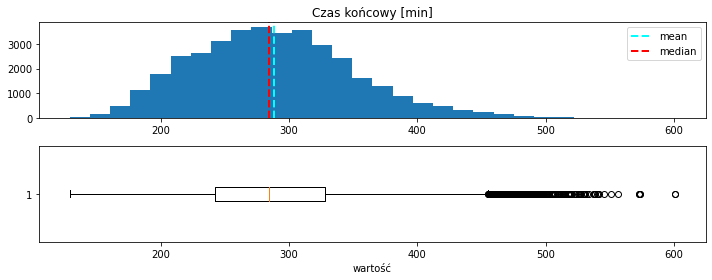

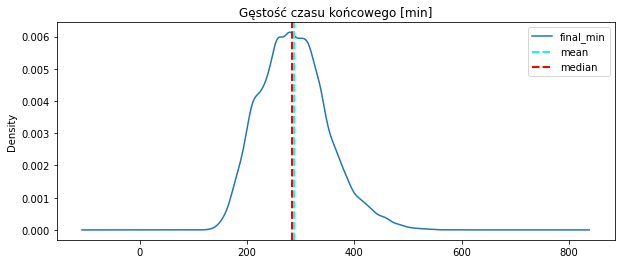

In [15]:
show_distribution(df['final_min'], title='Czas końcowy [min]')
show_density(df['final_min'], title='Gęstość czasu końcowego [min]')

## 6. Histogram i PDF
Krótka ciekawostka statystyczna: histogram jest dyskretny, a PDF to gładkie przybliżenie rozkładu ciągłego.


Histogram opisuje rozkład danych z próby, czyli to, co rzeczywiście zaobserwowaliśmy.  
PDF to gładka funkcja gęstości prawdopodobieństwa, czyli model ciągły, który próbujemy dopasować do danych.

Najpierw porównujemy histogram z prostym modelem normalnym.  
To jest dobry punkt odniesienia, ale trzeba pamiętać, że rozkład normalny jest **symetryczny**, a nasze dane wyglądają na **prawoskośne**.

Dlatego ten wykres należy czytać tak:
- histogram pokazuje rzeczywiste dane,
- PDF pokazuje model,
- a różnica między nimi mówi nam, czy dany model ma sens.

Dodatkowo sprawdzamy, jaki odsetek zawodników leży w zakresie `mean ± 1 std`.  
Dla idealnego rozkładu normalnego byłoby to około **68%**.  
Jeśli wynik jest zbliżony, to model normalny daje pewną intuicję, ale nie oznacza to jeszcze, że jest najlepszym rozkładem dla tych danych.

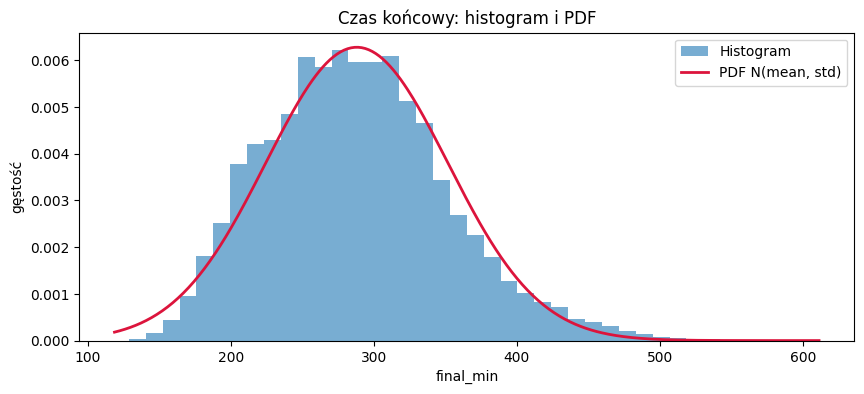

Odsetek biegaczy w zakresie mean ± 1 std: 68.20%


In [8]:
mu = df['final_min'].mean()
sigma = df['final_min'].std(ddof=1)
x = np.linspace(df['final_min'].min() - 10, df['final_min'].max() + 10, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10, 4))
plt.hist(df['final_min'], bins=40, density=True, alpha=0.6, label='Histogram')
plt.plot(x, pdf, color='crimson', linewidth=2, label='PDF N(mean, std)')
plt.title('Czas końcowy: histogram i PDF')
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.legend()
plt.show()

within_one_sigma = ((df['final_min'] >= mu - sigma) & (df['final_min'] <= mu + sigma)).mean()
print(f'Odsetek biegaczy w zakresie mean ± 1 std: {within_one_sigma:.2%}')

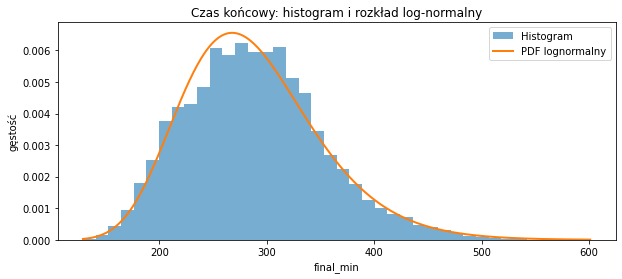

In [34]:
#from scipy import stats
#import numpy as np
#import matplotlib.pyplot as plt

x_data = df['final_min'].dropna()

shape, loc, scale = stats.lognorm.fit(x_data, floc=0)

x = np.linspace(x_data.min(), x_data.max(), 400)
pdf = stats.lognorm.pdf(x, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 4))
plt.hist(x_data, bins=40, density=True, alpha=0.6, label='Histogram')
plt.plot(x, pdf, linewidth=2, label='PDF lognormalny')
plt.title('Czas końcowy: histogram i rozkład log-normalny')
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.legend()
plt.show()

In [37]:
#from scipy import stats
#import numpy as np

x_data = df['final_min'].dropna()

# normalny
mu_norm, sigma_norm = stats.norm.fit(x_data)

# log-normalny
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(x_data, floc=0)
mu_log = np.log(scale_ln)
sigma_log = shape_ln

print("NORMALNY")
print("mu =", mu_norm)
print("sigma =", sigma_norm)

print("\nLOG-NORMALNY")
print("shape =", shape_ln)
print("loc =", loc_ln)
print("scale =", scale_ln)
print("mu_log =", mu_log)
print("sigma_log =", sigma_log)

NORMALNY
mu = 288.15505995525723
sigma = 63.53490291785799

LOG-NORMALNY
shape = 0.22181448217526858
loc = 0.0
scale = 281.22885453896254
mu_log = 5.639168766830715
sigma_log = 0.22181448217526858


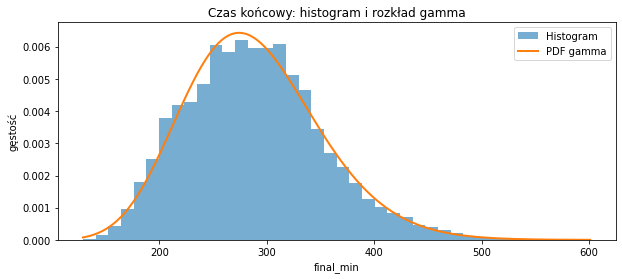

In [35]:
x_data = df['final_min'].dropna()

shape, loc, scale = stats.gamma.fit(x_data, floc=0)

x = np.linspace(x_data.min(), x_data.max(), 400)
pdf = stats.gamma.pdf(x, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 4))
plt.hist(x_data, bins=40, density=True, alpha=0.6, label='Histogram')
plt.plot(x, pdf, linewidth=2, label='PDF gamma')
plt.title('Czas końcowy: histogram i rozkład gamma')
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.legend()
plt.show()

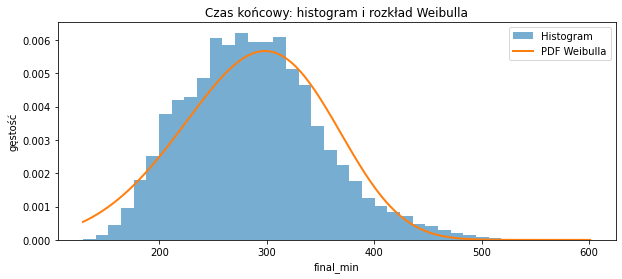

In [36]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

x_data = df['final_min'].dropna()

shape, loc, scale = stats.weibull_min.fit(x_data, floc=0)

x = np.linspace(x_data.min(), x_data.max(), 400)
pdf = stats.weibull_min.pdf(x, shape, loc=loc, scale=scale)

plt.figure(figsize=(10, 4))
plt.hist(x_data, bins=40, density=True, alpha=0.6, label='Histogram')
plt.plot(x, pdf, linewidth=2, label='PDF Weibulla')
plt.title('Czas końcowy: histogram i rozkład Weibulla')
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.legend()
plt.show()

### 6a. Porównanie wizualne różnych rozkładów

Rozkład normalny jest najprostszy, ale nie zawsze najlepiej opisuje dane.  
Czasy biegu są dodatnie i często mają prawy ogon, więc warto sprawdzić także inne rozkłady.

Najczęściej sensowne kandydaty to:

**Rozkład normalny**
- symetryczny,
- dobry jako punkt odniesienia,
- najlepiej działa dla danych bez wyraźnej skośności.

Wzór:
$ f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) $

**Rozkład lognormalny**
- zmienna jest zawsze dodatnia,
- dobrze opisuje dane prawoskośne,
- sensowny dla czasów, kosztów, długości i innych wielkości dodatnich.

Jeśli $Y = \ln X$ ma rozkład normalny, to $X$ ma rozkład lognormalny.

Wzór:
$ f(x) = \frac{1}{x \sigma \sqrt{2\pi}} \exp\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right), \quad x > 0 $

**Rozkład gamma**
- też jest dodatni i prawoskośny,
- dobrze nadaje się do modelowania czasów oczekiwania i dodatnich wielkości ciągłych,
- bywa bardziej elastyczny niż lognormalny.

Wzór:
$ f(x) = \frac{1}{\Gamma(k)\theta^k} x^{k-1} e^{-x/\theta}, \quad x > 0 $

**Rozkład Weibulla**
- dodatni,
- często używany do modelowania czasów życia, awarii i czasu do zdarzenia,
- może przyjmować różne kształty w zależności od parametrów.

Wzór:
$ f(x) = \frac{k}{\lambda} \left(\frac{x}{\lambda}\right)^{k-1} e^{-(x/\lambda)^k}, \quad x > 0 $

W praktyce:
- **normalny** traktujemy jako prosty model bazowy,
- **lognormalny** i **gamma** są naturalnymi kandydatami dla czasów biegu,
- **Weibull** też warto znać jako rozkład czasu do zdarzenia.

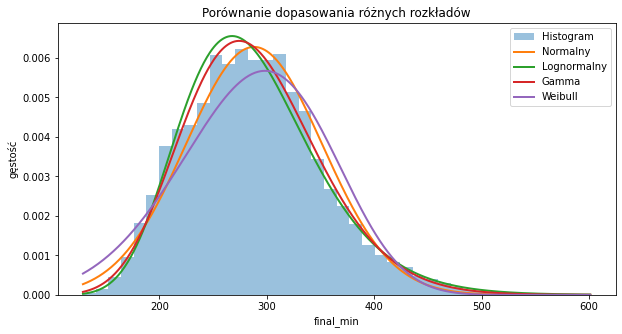

In [18]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

xdata = df['final_min'].dropna().values
x = np.linspace(xdata.min(), xdata.max(), 500)

# Dopasowania
mu, sigma = stats.norm.fit(xdata)
ln_shape, ln_loc, ln_scale = stats.lognorm.fit(xdata, floc=0)
ga_shape, ga_loc, ga_scale = stats.gamma.fit(xdata, floc=0)#GAMMA
wb_shape, wb_loc, wb_scale = stats.weibull_min.fit(xdata, floc=0)

pdf_norm = stats.norm.pdf(x, loc=mu, scale=sigma)
pdf_lognorm = stats.lognorm.pdf(x, s=ln_shape, loc=ln_loc, scale=ln_scale)
pdf_gamma = stats.gamma.pdf(x, a=ga_shape, loc=ga_loc, scale=ga_scale)#GAMMA
pdf_weibull = stats.weibull_min.pdf(x, c=wb_shape, loc=wb_loc, scale=wb_scale)

plt.figure(figsize=(10,5))
plt.hist(xdata, bins=40, density=True, alpha=0.45, label='Histogram')
plt.plot(x, pdf_norm, label='Normalny', linewidth=2)
plt.plot(x, pdf_lognorm, label='Lognormalny', linewidth=2)
plt.plot(x, pdf_gamma, label='Gamma', linewidth=2)#GAMMA
plt.plot(x, pdf_weibull, label='Weibull', linewidth=2)
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.title('Porównanie dopasowania różnych rozkładów')
plt.legend()
plt.show()

### Wniosek z dopasowania

Rozkład normalny jest prosty i wygodny, ale dla dodatnich, prawoskośnych danych lepszym kandydatem jest zwykle rozkład **lognormalny** albo **gamma**.

- W tym zbiorze model lognormalny / gamma opisuje dane lepiej niż normalny, więc normalny traktujemy raczej jako punkt odniesienia niż docelowy model.

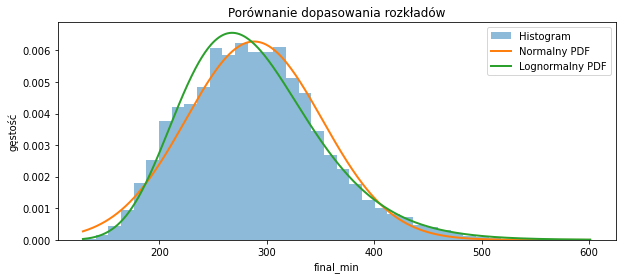

In [43]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

xdata = df['final_min'].dropna().values

# normalny
mu, sigma = stats.norm.fit(xdata)

# lognormalny
shape, loc, scale = stats.lognorm.fit(xdata, floc=0)

x = np.linspace(xdata.min(), xdata.max(), 500)

pdf_norm = stats.norm.pdf(x, loc=mu, scale=sigma)
pdf_lognorm = stats.lognorm.pdf(x, s=shape, loc=loc, scale=scale)

#ga_shape, ga_loc, ga_scale = stats.gamma.fit(xdata, floc=0)#GAMMA
#pdf_gamma = stats.gamma.pdf(x, a=ga_shape, loc=ga_loc, scale=ga_scale)#GAMMA
plt.figure(figsize=(10,4))
plt.hist(xdata, bins=40, density=True, alpha=0.5, label='Histogram')
plt.plot(x, pdf_norm, label='Normalny PDF', linewidth=2)
#plt.plot(x, pdf_gamma, label='Gamma', linewidth=2)#GAMMA
plt.plot(x, pdf_lognorm, label='Lognormalny PDF', linewidth=2)
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.title('Porównanie dopasowania rozkładów')
plt.legend()
plt.show()

### Jak porównać, który rozkład pasuje najlepiej?

Aby porównać dopasowanie różnych rozkładów do tych samych danych, możemy użyć kilku prostych miar.

#### 1. Log-likelihood
Log-likelihood mierzy, jak dobrze dany model opisuje obserwowane dane.  
Dla tego kryterium:
- **większa wartość** oznacza **lepsze dopasowanie**.

W praktyce wartości bywają ujemne, więc „większa” oznacza po prostu „mniej ujemna”.

#### 2. AIC
AIC to kryterium jakości dopasowania z lekką karą za liczbę parametrów modelu.  
Dla AIC:
- **mniejsza wartość** oznacza **lepszy model**.

#### 3. BIC
BIC działa podobnie do AIC, ale zwykle mocniej karze bardziej złożone modele.  
Dla BIC:
- **mniejsza wartość** oznacza **lepszy model**.

### Wniosek
Jeśli porównujemy kilka rozkładów dopasowanych do tych samych danych, to:
- patrzymy na **największy log-likelihood**,
- albo na **najmniejsze AIC/BIC**.

To pozwala wybrać model, który najlepiej opisuje dane, a nie tylko „ładnie wygląda” na wykresie.

Porównanie dopasowania:

In [38]:
ll_norm = np.sum(stats.norm.logpdf(x_data, mu_norm, sigma_norm))
ll_lognorm = np.sum(stats.lognorm.logpdf(x_data, shape_ln, loc_ln, scale_ln))
ll_gamma = np.sum(stats.gamma.logpdf(x_data, shape, loc=loc, scale=scale))

print("log-likelihood:")
print("normalny:", ll_norm)
print("log-normalny:", ll_lognorm)
print("gamma:", ll_gamma)

log-likelihood:
normalny: -207502.16577802197
log-normalny: -206819.20369126566
gamma: -366695.6772895577


In [39]:
import numpy as np
import pandas as pd
from scipy import stats

x_data = df['final_min'].dropna().values
n = len(x_data)

# normalny
mu_norm, sigma_norm = stats.norm.fit(x_data)
ll_norm = np.sum(stats.norm.logpdf(x_data, loc=mu_norm, scale=sigma_norm))
k_norm = 2  # mu, sigma

# log-normalny
shape_ln, loc_ln, scale_ln = stats.lognorm.fit(x_data, floc=0)
ll_lognorm = np.sum(stats.lognorm.logpdf(x_data, shape_ln, loc=loc_ln, scale=scale_ln))
k_lognorm = 2  # shape, scale (loc zamrożone na 0)

# gamma
shape_g, loc_g, scale_g = stats.gamma.fit(x_data, floc=0)
ll_gamma = np.sum(stats.gamma.logpdf(x_data, shape_g, loc=loc_g, scale=scale_g))
k_gamma = 2  # shape, scale (loc zamrożone na 0)

# Weibull
shape_w, loc_w, scale_w = stats.weibull_min.fit(x_data, floc=0)
ll_weibull = np.sum(stats.weibull_min.logpdf(x_data, shape_w, loc=loc_w, scale=scale_w))
k_weibull = 2  # shape, scale (loc zamrożone na 0)

def aic(ll, k):
    return 2 * k - 2 * ll

def bic(ll, k, n):
    return k * np.log(n) - 2 * ll

results = pd.DataFrame({
    'rozkład': ['normalny', 'log-normalny', 'gamma', 'Weibull'],
    'loglik': [ll_norm, ll_lognorm, ll_gamma, ll_weibull],
    'AIC': [aic(ll_norm, k_norm), aic(ll_lognorm, k_lognorm), aic(ll_gamma, k_gamma), aic(ll_weibull, k_weibull)],
    'BIC': [bic(ll_norm, k_norm, n), bic(ll_lognorm, k_lognorm, n), bic(ll_gamma, k_gamma, n), bic(ll_weibull, k_weibull, n)],
})

results = results.sort_values('AIC')
results

,rozkład,loglik,AIC,BIC
2,gamma,-206763.431557,413530.863115,413547.913929
1,log-normalny,-206819.203691,413642.407383,413659.458197
0,normalny,-207502.165778,415008.331556,415025.382370
3,Weibull,-208733.253887,417470.507774,417487.558588


#### Dać Studentom teraz pobawić się rozkładami

## 7. Rozkład spowolnienia (`slowdown_min`)

### Rozkład spowolnienia

Zmienna `slowdown_min` mówi, o ile zawodnik stracił względem idealnie równego tempa.

Interpretacja:
- wartość dodatnia oznacza, że zawodnik zwolnił na drugiej połowie,
- wartość bliska zeru oznacza prawie równe tempo,
- wartość ujemna oznacza `negative split`, czyli szybszą drugą połowę.

Na histogramie widać, że większość zawodników ma dodatnie `slowdown_min`, więc typowy wzorzec to pewne spowolnienie po półmetku.  
Ujemne wartości występują, ale są znacznie rzadsze.

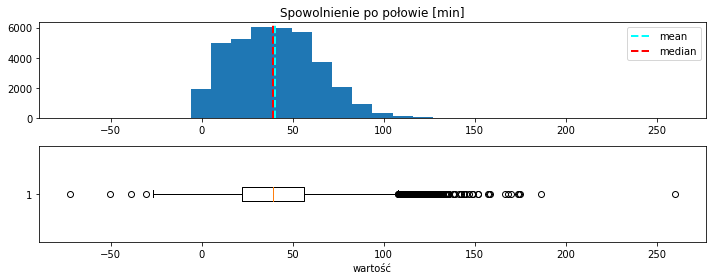

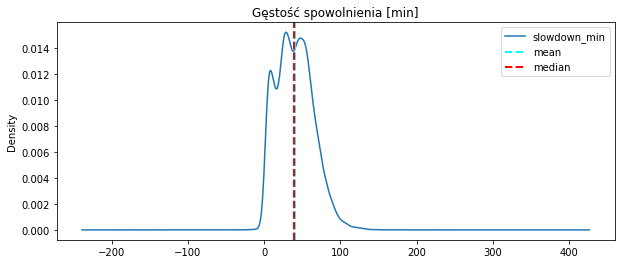

In [40]:
show_distribution(df['slowdown_min'], title='Spowolnienie po połowie [min]')
show_density(df['slowdown_min'], title='Gęstość spowolnienia [min]')

### Rozkład spowolnienia

`slowdown_min` mówi, o ile zawodnik stracił względem idealnie równego tempa.

- wartość dodatnia oznacza, że zawodnik zwolnił na drugiej połowie,
- wartość bliska zeru oznacza prawie równe tempo,
- wartość ujemna oznacza `negative split`, czyli szybszą drugą połowę.

Większość zawodników ma dodatnie `slowdown_min`, więc typowy wzorzec to pewne spowolnienie po półmetku.

- Widać, że większość ludzi spowalnia w drugiej połowie dystansu, ale garstka nie (ok.256), co widać w posortowanym .head() (od najlepszych) oraz na początku w describe.

In [44]:
df.head()

,age,gender,split,final,split_td,split_min,final_td,final_min,slowdown_min,slowdown_pct,negative_split,age_group
0,33,M,01:05:38,02:08:51,0 days 01:05:38,65.633333,0 days 02:08:51,128.850000,-2.416667,-1.875566,True,30-34
1,32,M,01:06:26,02:09:28,0 days 01:06:26,66.433333,0 days 02:09:28,129.466667,-3.400000,-2.626159,True,30-34
2,31,M,01:06:49,02:10:42,0 days 01:06:49,66.816667,0 days 02:10:42,130.700000,-2.933333,-2.244325,True,30-34
3,38,M,01:06:16,02:13:45,0 days 01:06:16,66.266667,0 days 02:13:45,133.750000,1.216667,0.909657,False,35-39
4,31,M,01:06:32,02:13:59,0 days 01:06:32,66.533333,0 days 02:13:59,133.983333,0.916667,0.684165,False,30-34


## 8. Relacja między split i final
Tutaj bardzo dobrze działa scatter, korelacja i prosta regresji.

### Relacja między `split` i `final`

Tutaj sprawdzamy zależność między czasem na półmetku (`split_min`) a czasem końcowym (`final_min`).

Scatter pokazuje, że zależność jest bardzo silna: zawodnicy szybsi na pierwszej połowie zwykle mają też lepszy wynik końcowy.  
Linia regresji pokazuje ogólny trend, a współczynnik korelacji mówi, jak silna jest zależność liniowa.

Ważna uwaga interpretacyjna:
ta zależność jest częściowo **konstrukcyjna**, bo czas końcowy zawiera w sobie czas z pierwszej połowy.  
Dlatego korelacja jest tu naturalnie bardzo wysoka i nie należy interpretować jej jako „zaskakającego odkrycia”, tylko raczej jako potwierdzenie spójności danych.

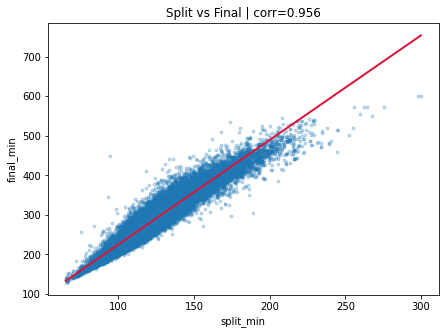

m = 2.6491, b = -40.0905, r = 0.9556, p = 0


In [45]:

corr = df['split_min'].corr(df['final_min'])
m, b, r, p, se = stats.linregress(df['split_min'], df['final_min'])

x_line = np.linspace(df['split_min'].min(), df['split_min'].max(), 200)
y_line = m * x_line + b

plt.figure(figsize=(7, 5))
plt.scatter(df['split_min'], df['final_min'], s=8, alpha=0.25)
plt.plot(x_line, y_line, color='crimson', linewidth=2)
plt.title(f'Split vs Final | corr={corr:.3f}')
plt.xlabel('split_min')
plt.ylabel('final_min')
plt.show()

print(f'm = {m:.4f}, b = {b:.4f}, r = {r:.4f}, p = {p:.4g}')


### Relacja między `split` i `final`

Zależność jest bardzo silna, ale trzeba pamiętać, że jest częściowo **konstrukcyjna**:
czas końcowy zawiera w sobie czas z pierwszej połowy.

> Ten wykres nie jest „odkryciem”, tylko raczej sprawdzeniem spójności danych i intuicji, że szybszy półmaraton zwykle wiąże się z lepszym wynikiem końcowym.

In [46]:
df.groupby('age_group')['negative_split'].mean().sort_values()

age_group
16-19    0.000000
65-69    0.000000
60-64    0.001878
55-59    0.003958
50-54    0.004478
45-49    0.004809
35-39    0.005168
70+      0.006024
40-44    0.007146
20-24    0.008361
25-29    0.010127
30-34    0.011056
Name: negative_split, dtype: float64

In [47]:
n_negative = df['negative_split'].sum()
n_all = len(df)
print(f"Negative split: {n_negative} z {n_all} ({100*n_negative/n_all:.2f}%)")

Negative split: 251 z 37250 (0.67%)


In [48]:
df.sort_values('final_min').head(10)

,age,gender,split,final,split_td,split_min,final_td,final_min,slowdown_min,slowdown_pct,negative_split,age_group
0,33,M,01:05:38,02:08:51,0 days 01:05:38,65.633333,0 days 02:08:51,128.850000,-2.416667,-1.875566,True,30-34
1,32,M,01:06:26,02:09:28,0 days 01:06:26,66.433333,0 days 02:09:28,129.466667,-3.400000,-2.626159,True,30-34
2,31,M,01:06:49,02:10:42,0 days 01:06:49,66.816667,0 days 02:10:42,130.700000,-2.933333,-2.244325,True,30-34
3,38,M,01:06:16,02:13:45,0 days 01:06:16,66.266667,0 days 02:13:45,133.750000,1.216667,0.909657,False,35-39
4,31,M,01:06:32,02:13:59,0 days 01:06:32,66.533333,0 days 02:13:59,133.983333,0.916667,0.684165,False,30-34
5,31,M,01:06:13,02:14:11,0 days 01:06:13,66.216667,0 days 02:14:11,134.183333,1.750000,1.304186,False,30-34
6,27,M,01:06:40,02:14:28,0 days 01:06:40,66.666667,0 days 02:14:28,134.466667,1.133333,0.842836,False,25-29
7,31,M,01:06:31,02:15:16,0 days 01:06:31,66.516667,0 days 02:15:16,135.266667,2.233333,1.651060,False,30-34
8,30,M,01:05:39,02:15:57,0 days 01:05:39,65.650000,0 days 02:15:57,135.950000,4.650000,3.420375,False,30-34
9,30,M,01:05:40,02:16:39,0 days 01:05:40,65.666667,0 days 02:16:39,136.650000,5.316667,3.890718,False,30-34


#### Porównanie miejsc końcowych do tych w split

In [51]:
df.sort_values('split_min').head(10)#.reset_index()

,age,gender,split,final,split_td,split_min,final_td,final_min,slowdown_min,slowdown_pct,negative_split,age_group
14,37,M,01:05:21,02:19:47,0 days 01:05:21,65.350000,0 days 02:19:47,139.783333,9.083333,6.498152,False,35-39
0,33,M,01:05:38,02:08:51,0 days 01:05:38,65.633333,0 days 02:08:51,128.850000,-2.416667,-1.875566,True,30-34
8,30,M,01:05:39,02:15:57,0 days 01:05:39,65.650000,0 days 02:15:57,135.950000,4.650000,3.420375,False,30-34
17,30,M,01:05:40,02:21:17,0 days 01:05:40,65.666667,0 days 02:21:17,141.283333,9.950000,7.042586,False,30-34
9,30,M,01:05:40,02:16:39,0 days 01:05:40,65.666667,0 days 02:16:39,136.650000,5.316667,3.890718,False,30-34
11,29,M,01:05:54,02:18:52,0 days 01:05:54,65.900000,0 days 02:18:52,138.866667,7.066667,5.088814,False,25-29
21,31,M,01:05:54,02:22:20,0 days 01:05:54,65.900000,0 days 02:22:20,142.333333,10.533333,7.400468,False,30-34
5,31,M,01:06:13,02:14:11,0 days 01:06:13,66.216667,0 days 02:14:11,134.183333,1.750000,1.304186,False,30-34
3,38,M,01:06:16,02:13:45,0 days 01:06:16,66.266667,0 days 02:13:45,133.750000,1.216667,0.909657,False,35-39
36,34,M,01:06:20,02:27:22,0 days 01:06:20,66.333333,0 days 02:27:22,147.366667,14.700000,9.975119,False,30-34


Powyżej ładnie widać różnice w pozycjach w połowie dystansu do pozycji końcowej.

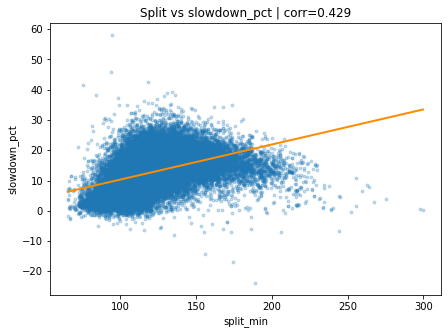

m = 0.1158, b = -1.2582, r = 0.4292, p = 0


In [53]:
corr_slow = df['split_min'].corr(df['slowdown_pct'])
m2, b2, r2, p2, se2 = stats.linregress(df['split_min'], df['slowdown_pct'])

x_line = np.linspace(df['split_min'].min(), df['split_min'].max(), 200)
y_line = m2 * x_line + b2

plt.figure(figsize=(7, 5))
plt.scatter(df['split_min'], df['slowdown_pct'], s=8, alpha=0.25)
plt.plot(x_line, y_line, color='darkorange', linewidth=2)
plt.title(f'Split vs slowdown_pct | corr={corr_slow:.3f}')
plt.xlabel('split_min')
plt.ylabel('slowdown_pct')
plt.show()

print(f'm = {m2:.4f}, b = {b2:.4f}, r = {r2:.4f}, p = {p2:.4g}')

### Pierwsza połowa a późniejsze spowolnienie

Ten wykres pokazuje coś ciekawszego niż `split vs final`:
czy poziom na pierwszej połowie wiąże się także ze strategią biegu.

W tym zbiorze wolniejszy półmaraton wiąże się przeciętnie z większym spowolnieniem procentowym, co sugeruje, że słabsi biegacze nie tylko biegną wolniej, ale też gorzej utrzymują tempo.

## 9. Boxplot czasu końcowego względem płci

### Boxplot czasu końcowego względem płci

Boxplot pozwala porównać rozkład czasu końcowego w dwóch grupach.

Widzimy tu nie tylko średni lub typowy poziom wyników, ale także:
- medianę,
- rozstęp międzykwartylowy,
- obserwacje odstające.

To jest wygodny sposób porównania grup, gdy chcemy zobaczyć nie tylko „kto ma niższą średnią”, ale też jak duża jest zmienność wyników w każdej grupie.

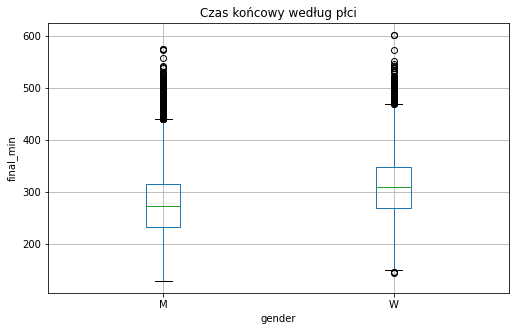

,gender,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
0,M,24665,276.48,272.55,119.15,38.17,12.80,0.01
1,W,12585,311.04,308.73,133.22,44.60,13.66,0.00


In [54]:
df.boxplot(column='final_min', by='gender', figsize=(8, 5))
plt.title('Czas końcowy według płci')
plt.suptitle('')
plt.xlabel('gender')
plt.ylabel('final_min')
plt.show()

summary_gender = (
    df.groupby('gender')
    .agg(
        n=('final_min', 'size'),
        mean_final=('final_min', 'mean'),
        median_final=('final_min', 'median'),
        mean_split=('split_min', 'mean'),
        mean_slowdown=('slowdown_min', 'mean'),
        mean_slowdown_pct=('slowdown_pct', 'mean'),
        negative_split_share=('negative_split', 'mean')
    )
    .reset_index()
    .round(2)
)

summary_gender

### Jak czytać porównanie płci?

Boxplot pokazuje, że rozkład jest podobny dla obu płci, ale przesunięty:
kobiety mają przeciętnie wyższe czasy niż mężczyźni.

Tabela liczbowa pozwala to od razu sprawdzić na medianie, średniej, spowolnieniu i odsetku `negative split`.

### Wartości odstające (outliery)

Punkty poza boxplotem to wartości odstające.

Są to obserwacje, które leżą poza typowym zakresem danych:
- znacznie wolniejsze lub szybsze niż większość,
- wyznaczane względem rozstępu międzykwartylowego (IQR).

W tym zbiorze widać głównie outliery po stronie wolniejszych czasów, co oznacza, że rozkład jest prawoskośny i ma długi ogon.

In [55]:
q1 = df['final_min'].quantile(0.25)
q3 = df['final_min'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Zakres bez outlierów: [{lower:.2f}, {upper:.2f}]")

Q1: 242.40, Q3: 327.60
IQR: 85.20
Zakres bez outlierów: [114.60, 455.40]


In [61]:
iqr_gender = df.groupby('gender')['final_min'].agg(
    q1=lambda x: x.quantile(0.25),
    median='median',
    q3=lambda x: x.quantile(0.75)
)

iqr_gender['IQR'] = iqr_gender['q3'] - iqr_gender['q1']
iqr_gender['lower_bound'] = iqr_gender['q1'] - 1.5 * iqr_gender['IQR']
iqr_gender['upper_bound'] = iqr_gender['q3'] + 1.5 * iqr_gender['IQR']

iqr_gender.round(2)

,q1,median,q3,IQR,lower_bound,upper_bound
gender,,,,,,
M,231.77,272.55,314.92,83.15,107.04,439.64
W,267.60,308.73,347.87,80.27,147.20,468.27


## 10. `groupby`: grupy wiekowe
Liczymy liczebność, średnią, medianę i przeciętne spowolnienie.

### Grupy wiekowe

In [58]:

age_summary = (
    df.groupby('age_group', observed=False)
      .agg(
          n=('final_min', 'size'),
          mean_final=('final_min', 'mean'),
          median_final=('final_min', 'median'),
          mean_split=('split_min', 'mean'),
          mean_slowdown=('slowdown_min', 'mean'),
          mean_slowdown_pct=('slowdown_pct', 'mean'),
          negative_split_share=('negative_split', 'mean')
      )
      .reset_index()
)

age_summary.round(3)


,age_group,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
0,16-19,131,300.768,290.933,127.562,45.643,14.630,0.000
1,20-24,1196,287.348,287.892,122.291,42.766,13.894,0.008
2,25-29,4246,284.860,282.733,122.266,40.327,13.189,0.010
3,30-34,5608,281.002,277.675,121.075,38.852,12.845,0.011
4,35-39,6386,282.096,278.683,121.670,38.756,12.764,0.005
5,40-44,6857,280.559,277.367,121.311,37.936,12.577,0.007
6,45-49,5406,286.519,282.142,123.507,39.506,12.929,0.005
7,50-54,3796,296.551,293.450,127.149,42.253,13.455,0.004
8,55-59,2021,309.561,306.133,132.094,45.372,13.986,0.004
9,60-64,1065,328.888,321.117,138.975,50.939,14.988,0.002


### Podsumowanie statystyk według grup wiekowych

Grupujemy dane po `age_group` i liczymy najważniejsze statystyki dla każdej grupy:

- liczność (`n`)
- średni i medianowy czas końcowy
- średni czas na półmetku
- średnie spowolnienie
- średnie spowolnienie procentowe
- odsetek zawodników z `negative split`

Dzięki temu możemy porównać nie pojedynczych zawodników, ale całe grupy wiekowe.

👉 Uwaga: `negative_split` jest typu True/False, więc jego średnia to po prostu **odsetek takich zawodników** w danej grupie.

### Płeć

In [57]:
gender_summary = (
    df.groupby('gender')
    .agg(
        n=('final_min', 'size'),
        mean_final=('final_min', 'mean'),
        median_final=('final_min', 'median'),
        mean_split=('split_min', 'mean'),
        mean_slowdown=('slowdown_min', 'mean'),
        mean_slowdown_pct=('slowdown_pct', 'mean'),
        negative_split_share=('negative_split', 'mean')
    )
    .reset_index()
    .round(2)
)

summary

,gender,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
0,M,24665,276.48,272.55,119.15,38.17,12.80,0.01
1,W,12585,311.04,308.73,133.22,44.60,13.66,0.00


### Podsumowanie statystyk według płci

Grupujemy dane po `gender` i liczymy najważniejsze statystyki:

- liczność (`n`)
- średni i medianowy czas końcowy
- średni czas na półmetku
- średnie spowolnienie
- średnie spowolnienie procentowe
- odsetek zawodników z `negative split`

👉 Uwaga: `negative_split` jest typu True/False, więc jego średnia to po prostu **procent takich zawodników**.

### Które grupy wiekowe są najszybsze?

Sortujemy grupy wiekowe według:
- średniego czasu końcowego (`mean_final`),
- mediany czasu końcowego (`median_final`).

To pozwala porównać wyniki na dwa sposoby:
- **średnia** uwzględnia wszystkie obserwacje, ale jest bardziej wrażliwa na skrajne wartości,
- **mediana** jest bardziej odporna na outliery i często lepiej opisuje „typowego” zawodnika.

Jeśli ranking według średniej i mediany jest podobny, to daje to bardziej stabilny obraz najszybszych grup.

In [59]:
print('Ranking po średniej:')
display(age_summary.sort_values('mean_final').head(5).round(2))

print('Ranking po medianie:')
display(age_summary.sort_values('median_final').head(5).round(2))

Ranking po średniej:


,age_group,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
5,40-44,6857,280.56,277.37,121.31,37.94,12.58,0.01
3,30-34,5608,281.00,277.67,121.08,38.85,12.85,0.01
4,35-39,6386,282.10,278.68,121.67,38.76,12.76,0.01
2,25-29,4246,284.86,282.73,122.27,40.33,13.19,0.01
6,45-49,5406,286.52,282.14,123.51,39.51,12.93,0.00


Ranking po medianie:


,age_group,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
5,40-44,6857,280.56,277.37,121.31,37.94,12.58,0.01
3,30-34,5608,281.00,277.67,121.08,38.85,12.85,0.01
4,35-39,6386,282.10,278.68,121.67,38.76,12.76,0.01
6,45-49,5406,286.52,282.14,123.51,39.51,12.93,0.00
2,25-29,4246,284.86,282.73,122.27,40.33,13.19,0.01


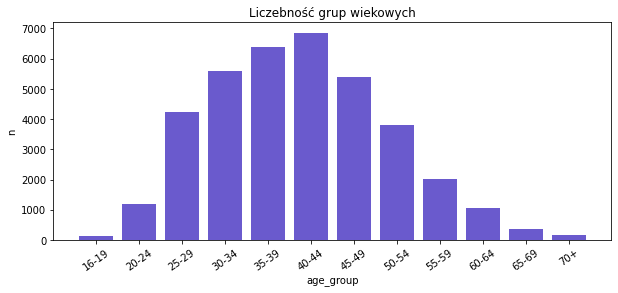

In [60]:
plt.figure(figsize=(10, 4))
plt.bar(age_summary['age_group'].astype(str), age_summary['n'], color='slateblue')
plt.title('Liczebność grup wiekowych')
plt.xlabel('age_group')
plt.ylabel('n')
plt.xticks(rotation=35)
plt.show()

### Wnioski z wieku

- Najszybsze grupy to zwykle zakres około **30–44 lat**.
- Średnia i mediana dają podobny ranking, więc obraz jest stabilny.
- Na skrajach wieku trzeba uważać, bo liczebności są dużo mniejsze.

### Wnioski z rankingu grup wiekowych

Na podstawie średniego i medianowego czasu końcowego widać, że najszybsze są grupy w środkowym wieku dorosłym, szczególnie około **30–44 lat**.

To sugeruje, że najlepsze wyniki osiągają nie najmłodsi i nie najstarsi zawodnicy, ale raczej biegacze w wieku, w którym łączą:
- dobrą wydolność,
- doświadczenie treningowe,
- stabilną strategię biegu.

Warto jednak pamiętać, że różnice między sąsiednimi grupami nie są bardzo duże, więc nie należy ich nadinterpretować.

### Uwaga na wiarygodność: liczebność grup

Porównując grupy, trzeba patrzeć nie tylko na średnie i mediany, ale też na **liczebność**.

Dlaczego to ważne?
- duże grupy dają zwykle stabilniejsze oszacowania,
- małe grupy mogą wyglądać bardzo dobrze lub bardzo słabo przez przypadek,
- skrajne wyniki w małej grupie mają większy wpływ na średnią i medianę.

Dlatego ranking grup wiekowych należy interpretować razem z wykresem liczebności.

### Wnioski o wiarygodności porównań

Największą ostrożność trzeba zachować przy najmłodszych i najstarszych grupach wiekowych, ponieważ ich liczebność jest znacznie mniejsza niż w grupach środkowych.

Oznacza to, że:
- wyniki tych grup mogą być mniej stabilne,
- pojedyncze skrajne obserwacje mają tam większy wpływ,
- ranking grup należy czytać razem z liczebnością próby.

Najbardziej wiarygodne wnioski dotyczą więc grup o dużej liczbie zawodników.

## 11. Bonus: rozkłady po grupach wiekowych

Tabela `groupby` pokazuje średnie i mediany, ale nie pokazuje kształtu rozkładu.  
Dlatego oglądamy histogramy osobno dla każdej grupy wiekowej.

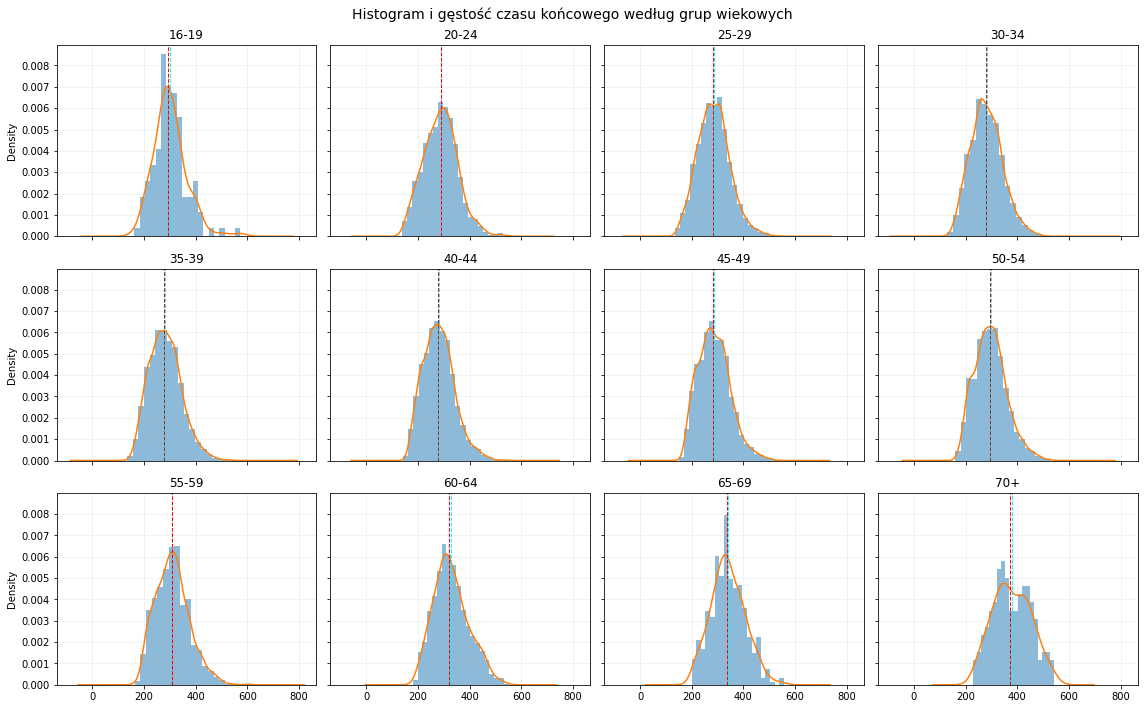

In [62]:
groups = age_labels
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, groups):
    sub = df[df['age_group'] == group]['final_min'].dropna()
    sub.plot(kind='hist', bins=20, density=True, alpha=0.5, ax=ax)
    sub.plot(kind='density', ax=ax)
    ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
    ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)
    ax.set_title(str(group))
    ax.grid(alpha=0.2)

for ax in axes[len(groups):]:
    ax.axis('off')

fig.suptitle('Histogram i gęstość czasu końcowego według grup wiekowych', fontsize=14)
fig.tight_layout()
plt.show()

### Wnioski z rozkładów po wieku

- rozkłady są prawoskośne w każdej grupie,
- najszybsze grupy są przesunięte najbardziej w lewo,
- starsze grupy mają zwykle szersze rozkłady,
- na krańcach wieku histogramy są mniej stabilne, bo próbki są małe.

### BOUNUS : histogramy/grupy wiekowe - bez i z dopasowaniami

### Rozkład czasu końcowego w grupach wiekowych

Tabela `groupby` pokazuje średnie i mediany, ale nie pokazuje kształtu rozkładu.

Dlatego rysujemy histogramy osobno dla każdej grupy wiekowej.  
To pozwala porównać:
- położenie rozkładu,
- jego szerokość,
- skośność,
- obecność wartości odstających.

Dzięki temu widzimy nie tylko *która grupa jest szybsza średnio*, ale też *jak wyglądają całe rozkłady wyników*.

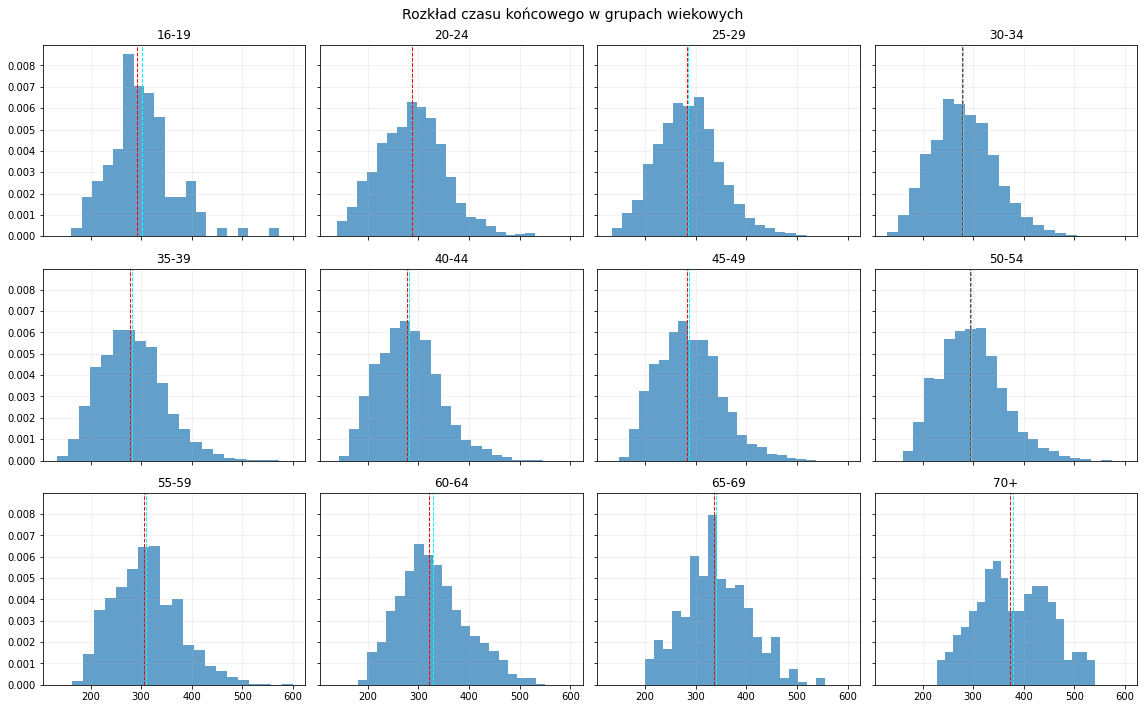

In [21]:
import matplotlib.pyplot as plt

groups = age_labels  # albo sorted(df['age_group'].dropna().unique())
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, groups):
    sub = df[df['age_group'] == group]['final_min'].dropna()
    ax.hist(sub, bins=20, alpha=0.7, density=True)
    ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1, label='mean')
    ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1, label='median')
    ax.set_title(str(group))
    ax.grid(alpha=0.2)

# jeśli subplotów jest więcej niż grup
for ax in axes[len(groups):]:
    ax.axis('off')

fig.suptitle('Rozkład czasu końcowego w grupach wiekowych', fontsize=14)
fig.tight_layout()
plt.show()

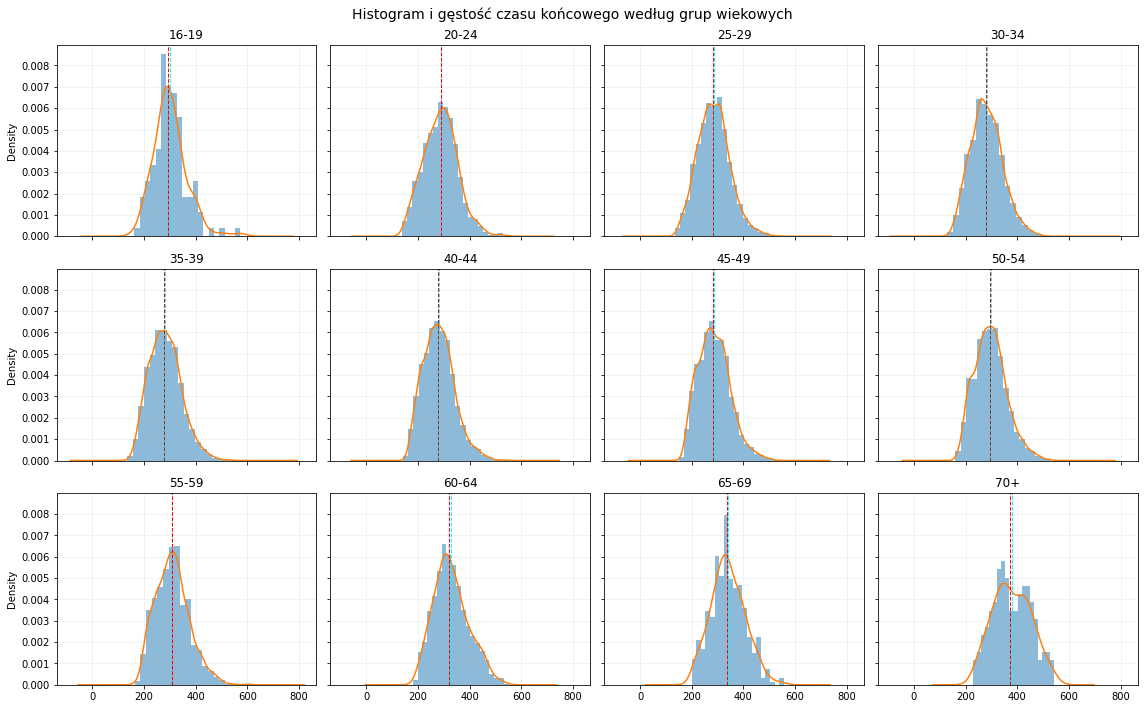

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, groups):
    sub = df[df['age_group'] == group]['final_min'].dropna()
    sub.plot(kind='hist', bins=20, density=True, alpha=0.5, ax=ax)
    sub.plot(kind='density', ax=ax)
    ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
    ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)
    ax.set_title(str(group))
    ax.grid(alpha=0.2)

for ax in axes[len(groups):]:
    ax.axis('off')

fig.suptitle('Histogram i gęstość czasu końcowego według grup wiekowych', fontsize=14)
fig.tight_layout()
plt.show()

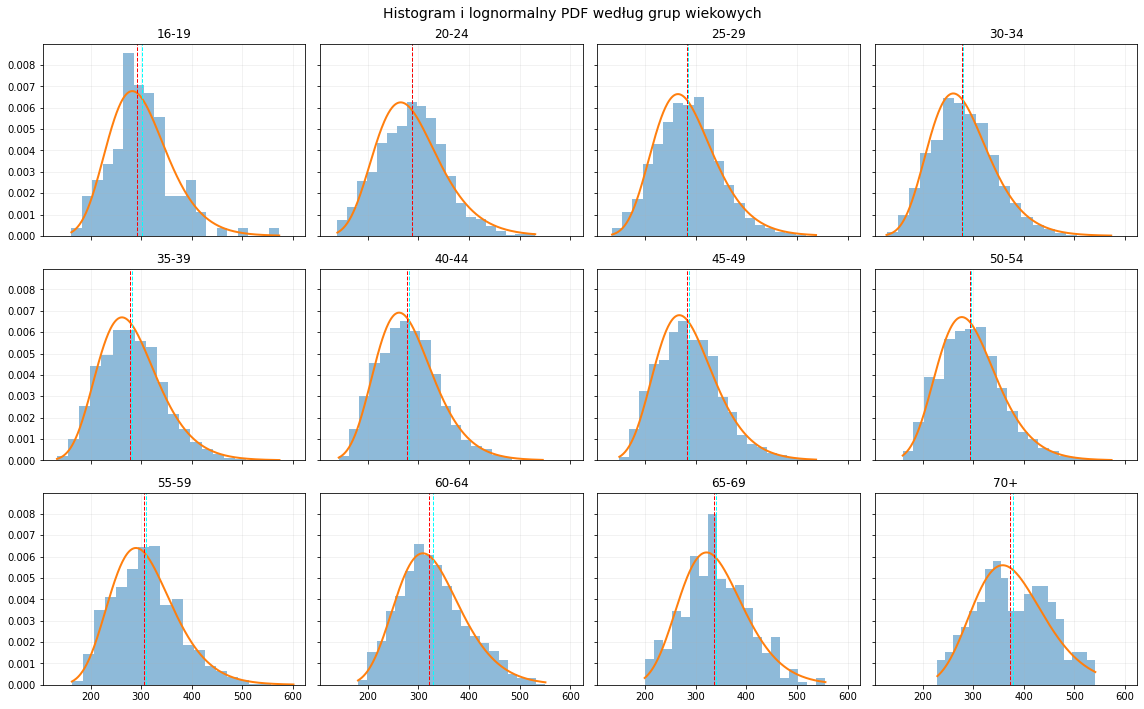

In [23]:
from scipy import stats
import numpy as np

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, group in zip(axes, groups):
    sub = df[df['age_group'] == group]['final_min'].dropna()
    ax.hist(sub, bins=20, density=True, alpha=0.5)

    if len(sub) > 30:  # żeby nie dopasowywać na zbyt małej próbce
        shape, loc, scale = stats.lognorm.fit(sub, floc=0)
        x = np.linspace(sub.min(), sub.max(), 300)
        pdf = stats.lognorm.pdf(x, s=shape, loc=loc, scale=scale)
        ax.plot(x, pdf, linewidth=2)

    ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
    ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)
    ax.set_title(str(group))
    ax.grid(alpha=0.2)

for ax in axes[len(groups):]:
    ax.axis('off')

fig.suptitle('Histogram i lognormalny PDF według grup wiekowych', fontsize=14)
fig.tight_layout()
plt.show()

### Wnioski z rozkładów czasu końcowego według grup wiekowych

Analizując histogramy i gęstości dla poszczególnych grup wiekowych, możemy zauważyć kilka istotnych rzeczy:

**1. Rozkład jest prawoskośny we wszystkich grupach**
- większość zawodników skupia się wokół typowego czasu,
- ale występuje długi ogon po stronie wolniejszych wyników,
- oznacza to, że czas biegu ma naturalne ograniczenie od dołu, ale może być znacznie wydłużony.

**2. Najszybsze grupy znajdują się w średnim wieku**
- szczególnie grupy około **30–44 lat** mają rozkłady przesunięte najbardziej w lewo,
- oznacza to niższe typowe czasy (lepsze wyniki).

**3. Wraz z wiekiem rozkład przesuwa się w prawo**
- starsze grupy mają wyższe mediany i średnie,
- czyli typowy czas biegu rośnie wraz z wiekiem.

**4. Zmienność wyników rośnie dla starszych grup**
- histogramy i gęstości są bardziej rozciągnięte,
- oznacza to większe zróżnicowanie poziomu w tych grupach.

**5. Młodsze grupy są mniej stabilne statystycznie**
- rozkłady są mniej gładkie,
- wynika to z mniejszej liczebności i większego wpływu przypadku.

**6. Kształt rozkładu jest podobny między grupami**
- zmienia się głównie położenie (średnia/mediana),
- sam mechanizm rozkładu pozostaje podobny.

---

### Dopasowanie rozkładu

- rozkład normalny jest tylko przybliżeniem i nie oddaje skośności danych,
- rozkład **lognormalny** lepiej pasuje, ponieważ:
  - dane są dodatnie,
  - mają prawy ogon,
  - często opisują procesy multiplikatywne (np. zmęczenie, tempo).

👉 Wniosek: czasy maratońskie są lepiej modelowane rozkładem lognormalnym niż normalnym.

---

### Podsumowanie

- czasy biegu są dodatnie i prawoskośne,
- najszybsze wyniki osiągają zawodnicy w średnim wieku,
- wraz z wiekiem rośnie zarówno czas, jak i zmienność wyników,
- lognormalny model lepiej opisuje dane niż normalny.

---

➡️ Następny krok: porównanie rozkładów **w zależności od płci**, co pozwoli sprawdzić, czy te same zależności występują również między grupami `M` i `W`.

### Rozkład czasu końcowego według płci

Teraz analizujemy te same dane, ale dzieląc je według płci.

Chcemy sprawdzić:
- czy różnice dotyczą tylko średniej,
- czy także rozkładu wyników,
- oraz czy zmienność w grupach jest podobna.

### Tabela przestawna: wiek × płeć

Do tej pory analizowaliśmy:
- grupy wiekowe osobno,
- płeć osobno.

Teraz łączymy oba wymiary jednocześnie.

Tworzymy tabelę, w której:
- wiersze to grupy wiekowe (`age_group`),
- kolumny to płeć (`gender`),
- wartości to medianowy czas końcowy (`final_min`).

Dzięki temu możemy sprawdzić:
- czy różnice między płciami są podobne w każdej grupie wiekowej,
- czy pewne grupy wiekowe zachowują się inaczej,
- oraz czy zależności są stabilne, czy zmieniają się w zależności od kontekstu.

👉 To jest pierwszy krok od analizy jednowymiarowej do **analizy wielowymiarowej**.

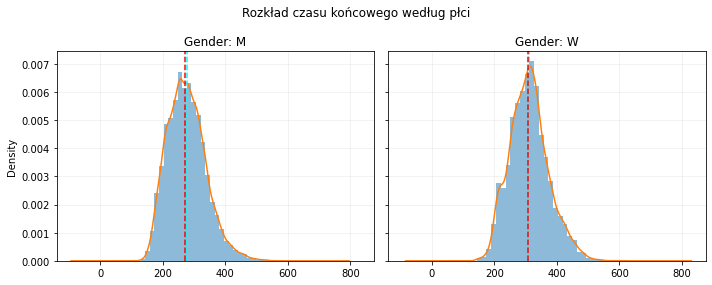

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, gender in zip(axes, ['M', 'W']):
    sub = df[df['gender'] == gender]['final_min'].dropna()
    
    ax.hist(sub, bins=30, density=True, alpha=0.5)
    sub.plot(kind='density', ax=ax)
    
    ax.axvline(sub.mean(), color='cyan', linestyle='--')
    ax.axvline(sub.median(), color='red', linestyle='--')
    
    ax.set_title(f'Gender: {gender}')
    ax.grid(alpha=0.2)

plt.suptitle('Rozkład czasu końcowego według płci')
plt.tight_layout()
plt.show()

### Płeć w ramach kategorii wiekowych

Teraz analizujemy dane w dwóch wymiarach jednocześnie:
- kategoria wiekowa (`age_group`),
- płeć (`gender`).

Zamiast patrzeć na płeć lub wiek osobno, sprawdzamy:
👉 jak różnią się wyniki kobiet i mężczyzn **w obrębie każdej grupy wiekowej**.

Tabela pokazuje medianowy czas końcowy:
- dla każdej kategorii wiekowej,
- osobno dla kobiet i mężczyzn.

Dzięki temu możemy odpowiedzieć na pytania:
- czy różnice między płciami są podob

### Porównanie płci w ramach grup wiekowych

Do tej pory analizowaliśmy:
- wpływ wieku na wyniki,
- wpływ płci na wyniki.

Teraz łączymy te dwa wymiary i sprawdzamy:

- jak wypadają kobiety i mężczyźni **w tej samej grupie wiekowej**,
- czy różnice między płciami są podobne w każdym wieku,
- czy w niektórych grupach wiekowych te różnice są większe lub mniejsze.

Tworzymy tabelę, w której:
- wiersze to grupy wiekowe,
- kolumny to płeć,
- wartości to czas końcowy.

👉 Dzięki temu przechodzimy od prostego porównania do **analizy kontekstowej** (czyli zależności zależnej od wieku).

## 12. `pivot_table`: wiek × płeć

Teraz łączymy dwa wymiary naraz i porównujemy kobiety i mężczyzn **w tej samej grupie wiekowej**.

In [68]:
pivot_mean = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc='mean',
    observed=False
)

pivot_median = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc='median',
    observed=False
)

pivot_count = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc='size',
    observed=False
)


pivot_mode = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc=lambda x: x.mode().iloc[0],
    observed=False
)

print('Średnia:')
display(pivot_mean.round(2))
print('Mediana:')
display(pivot_median.round(2))
print('Modalna:')
display(pivot_mode)
print('Liczebność:')
display(pivot_count)

Średnia:


gender,M,W
age_group,,
16-19,292.80,316.53
20-24,274.63,302.79
25-29,268.16,301.65
30-34,266.00,303.60
35-39,269.23,307.29
40-44,268.83,306.00
45-49,273.75,316.94
50-54,285.48,328.02
55-59,299.49,345.22


Mediana:


gender,M,W
age_group,,
16-19,285.27,317.28
20-24,275.49,302.34
25-29,264.60,301.33
30-34,261.12,302.68
35-39,264.62,305.75
40-44,265.20,304.67
45-49,270.23,316.21
50-54,282.03,321.23
55-59,297.64,336.55


Modalna:


gender,M,W
age_group,,
16-19,195.333333,162.100000
20-24,188.133333,203.550000
25-29,215.800000,267.800000
30-34,235.266667,260.533333
35-39,194.150000,284.033333
40-44,234.000000,274.050000
45-49,315.233333,265.533333
50-54,276.950000,275.166667
55-59,230.350000,266.716667


Liczebność:


gender,M,W
age_group,,
16-19,87,44
20-24,656,540
25-29,2129,2117
30-34,3370,2238
35-39,4227,2159
40-44,4693,2164
45-49,3808,1598
50-54,2808,988
55-59,1576,445


### Wartość modalna po zaokrągleniu do pełnych minut

In [69]:
df['final_min_round'] = df['final_min'].round()

pivot_mode_round = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min_round',
    aggfunc=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    observed=False
)

pivot_mode_round

gender,M,W
age_group,,
16-19,285.0,312.0
20-24,300.0,286.0
25-29,232.0,307.0
30-34,256.0,333.0
35-39,253.0,317.0
40-44,283.0,308.0
45-49,267.0,316.0
50-54,260.0,293.0
55-59,336.0,323.0


In [72]:
pivot_summary = pd.DataFrame({
    'M_median': pivot_median['M'],
    'W_median': pivot_median['W'],
    'M_mean': pivot_mean['M'],
    'W_mean': pivot_mean['W'],
    'M_mode': pivot_mode_round['M'],
    'W_mode': pivot_mode_round['W'],
    'M_n': pivot_count['M'],
    'W_n': pivot_count['W']
})

pivot_summary['W_minus_M_median'] = pivot_summary['W_median'] - pivot_summary['M_median']
pivot_summary.round(2)

,M_median,W_median,M_mean,W_mean,M_mode,W_mode,M_n,W_n,W_minus_M_median
age_group,,,,,,,,,
16-19,285.27,317.28,292.80,316.53,285.0,312.0,87,44,32.02
20-24,275.49,302.34,274.63,302.79,300.0,286.0,656,540,26.85
25-29,264.60,301.33,268.16,301.65,232.0,307.0,2129,2117,36.73
30-34,261.12,302.68,266.00,303.60,256.0,333.0,3370,2238,41.56
35-39,264.62,305.75,269.23,307.29,253.0,317.0,4227,2159,41.13
40-44,265.20,304.67,268.83,306.00,283.0,308.0,4693,2164,39.47
45-49,270.23,316.21,273.75,316.94,267.0,316.0,3808,1598,45.97
50-54,282.03,321.23,285.48,328.02,260.0,293.0,2808,988,39.20
55-59,297.64,336.55,299.49,345.22,336.0,323.0,1576,445,38.91


### Dać studentom teraz czas na analizę tabelki porównanie różnych statystyk - mean,median,mode dla grup wiekowych i płci.

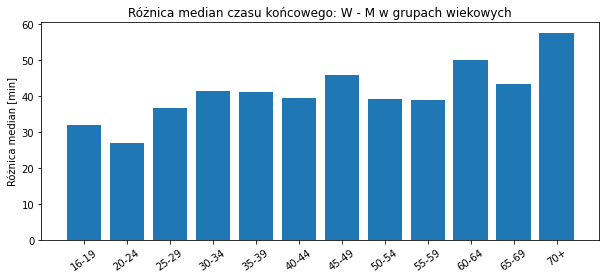

In [27]:
plt.figure(figsize=(10,4))
plt.bar(pivot_summary.index.astype(str), pivot_summary['W_minus_M_median'])
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=35)
plt.ylabel('Różnica median [min]')
plt.title('Różnica median czasu końcowego: W - M w grupach wiekowych')
plt.show()

### Rozkład czasu końcowego: grupa wiekowa × płeć

Teraz porównujemy rozkłady jeszcze dokładniej:
- w każdej grupie wiekowej,
- osobno dla kobiet i mężczyzn.

Dzięki temu możemy sprawdzić:
- czy różnice między płciami są podobne w każdym wieku,
- czy kształt rozkładu zmienia się wraz z wiekiem,
- oraz czy liczebność grup wpływa na stabilność obrazu.

### Wnioski z `wiek × płeć`

- Różnica między płciami jest obecna w każdej grupie wiekowej.
- Kształt rozkładu jest podobny, ale rozkład kobiet jest zwykle przesunięty w prawo.
- Najważniejszy efekt to **shift**, nie zmiana samego mechanizmu rozkładu.

## 13. Bonus: histogramy `wiek × płeć` - bez/z dopasowaniem krzywej

Tu patrzymy jeszcze dokładniej: dla każdej grupy wiekowej osobno oglądamy rozkład kobiet i mężczyzn.

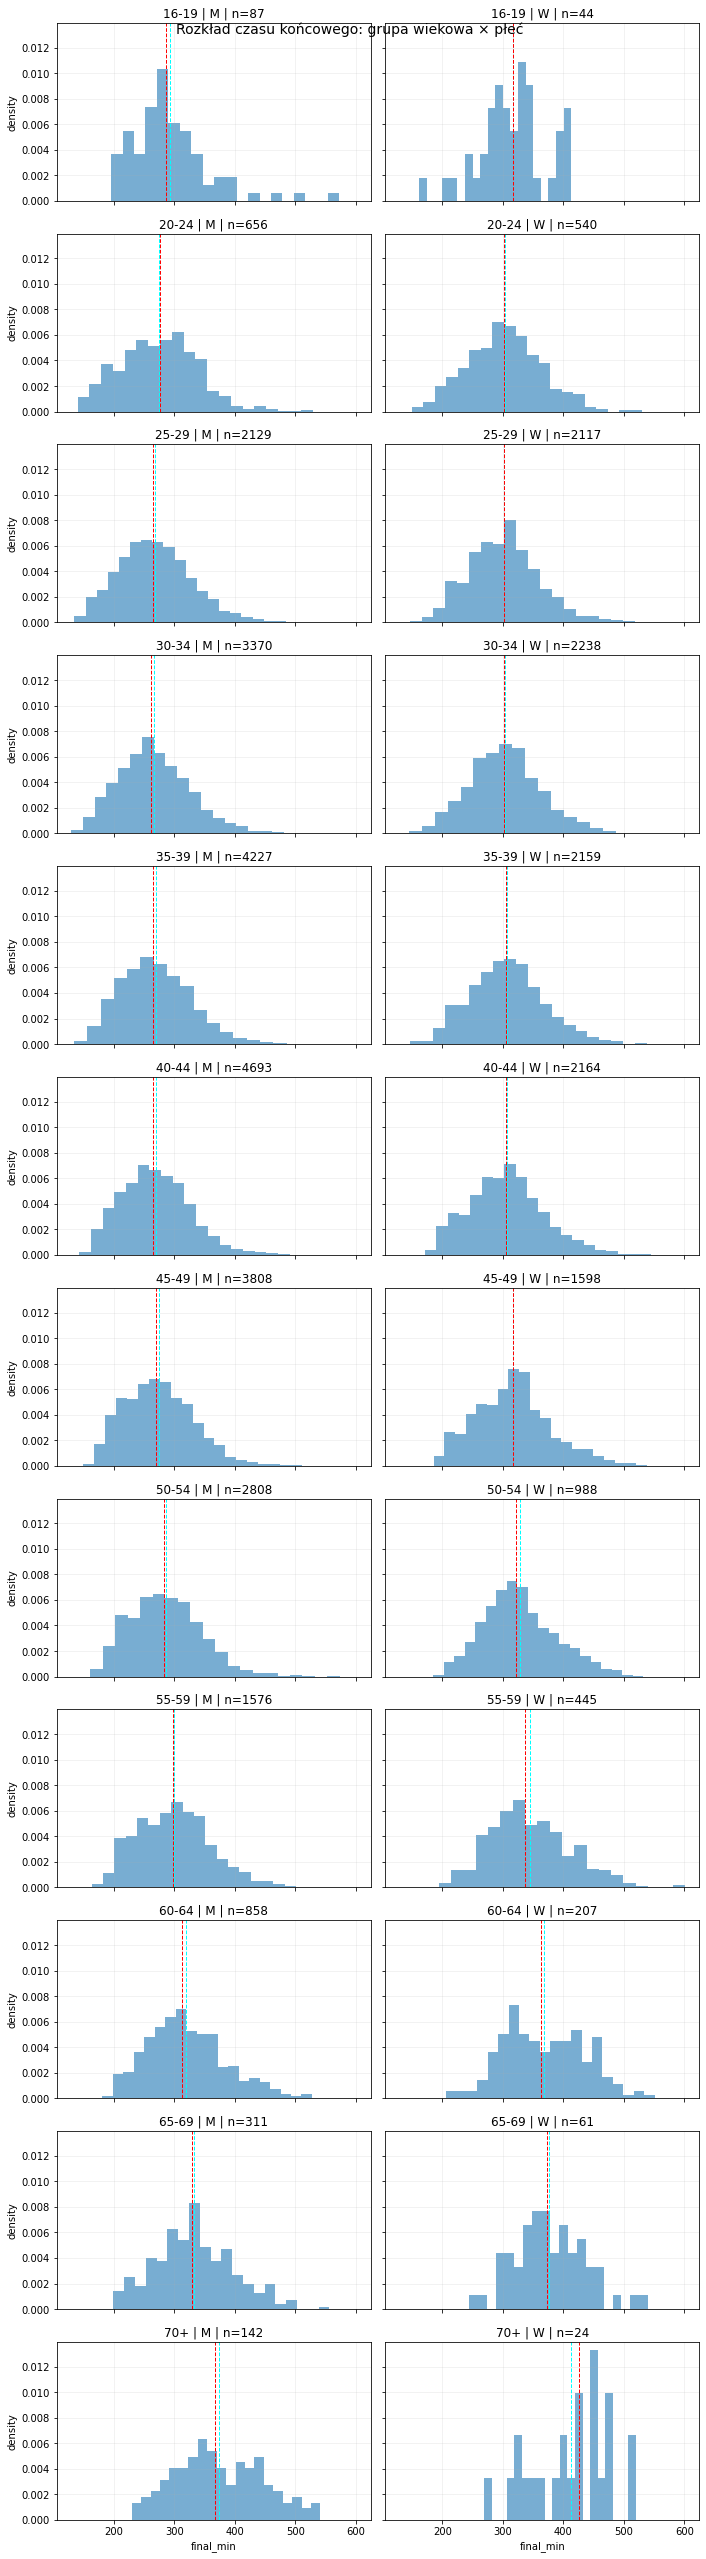

In [28]:
fig, axes = plt.subplots(len(age_labels), 2, figsize=(10, 3*len(age_labels)), sharex=True, sharey=True)

for i, group in enumerate(age_labels):
    for j, gender in enumerate(['M', 'W']):
        ax = axes[i, j]
        sub = df[(df['age_group'] == group) & (df['gender'] == gender)]['final_min'].dropna()

        ax.hist(sub, bins=20, density=True, alpha=0.6)

        if len(sub) > 5:
            ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1, label='mean')
            ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1, label='median')

        ax.set_title(f'{group} | {gender} | n={len(sub)}')
        ax.grid(alpha=0.2)

        if i == len(age_labels) - 1:
            ax.set_xlabel('final_min')
        if j == 0:
            ax.set_ylabel('density')

fig.suptitle('Rozkład czasu końcowego: grupa wiekowa × płeć', fontsize=14)
fig.tight_layout()
plt.show()

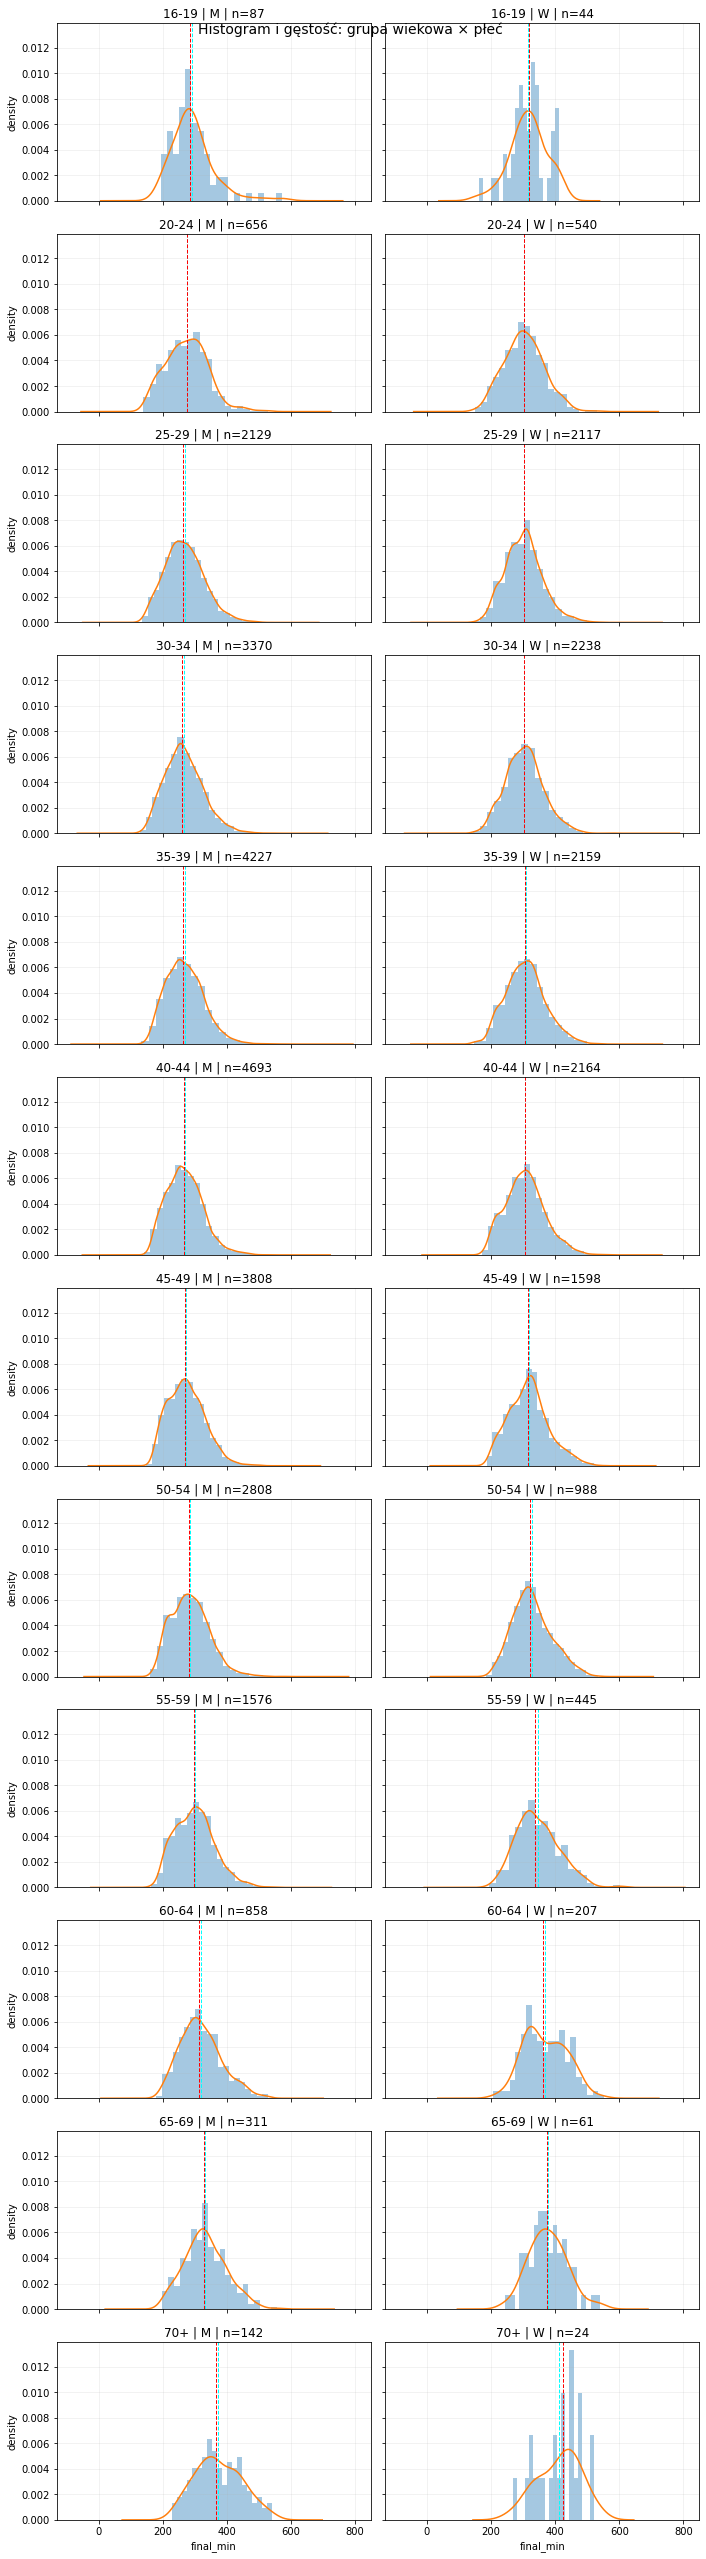

In [29]:
fig, axes = plt.subplots(len(age_labels), 2, figsize=(10, 3*len(age_labels)), sharex=True, sharey=True)

for i, group in enumerate(age_labels):
    for j, gender in enumerate(['M', 'W']):
        ax = axes[i, j]
        sub = df[(df['age_group'] == group) & (df['gender'] == gender)]['final_min'].dropna()

        sub.plot(kind='hist', bins=20, density=True, alpha=0.4, ax=ax)

        if len(sub) > 10:
            sub.plot(kind='density', ax=ax)

        if len(sub) > 5:
            ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
            ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)

        ax.set_title(f'{group} | {gender} | n={len(sub)}')
        ax.grid(alpha=0.2)

        if i == len(age_labels) - 1:
            ax.set_xlabel('final_min')
        if j == 0:
            ax.set_ylabel('density')

fig.suptitle('Histogram i gęstość: grupa wiekowa × płeć', fontsize=14)
fig.tight_layout()
plt.show()

### Wnioski z histogramów `wiek × płeć`

- kształt rozkładu jest podobny dla obu płci,
- różnica polega głównie na przesunięciu poziomu,
- w starszych grupach rośnie zmienność i maleje stabilność estymacji,
- małe grupy (np. 70+ kobiet) trzeba interpretować ostrożnie.

### Uwaga: histogram, KDE i fit rozkładu

W tym wykresie linia gęstości nie jest dopasowaniem konkretnego rozkładu teoretycznego.  
To jest **KDE** (kernel density estimate), czyli wygładzone oszacowanie gęstości na podstawie danych.

Jeśli chcemy porównać dane z konkretnym modelem statystycznym, musimy osobno dopasować np.:
- rozkład lognormalny,
- gamma,
- Weibulla,
- albo normalny jako punkt odniesienia.

Porównanie różnych dopasowań:

### Histogram i KDE

Histogram pokazuje dane w sposób dyskretny, a KDE daje ich wygładzone przybliżenie.

Ta wersja służy do porównania kształtu rozkładów:
- położenia,
- szerokości,
- skośności,
- i koncentracji wyników.

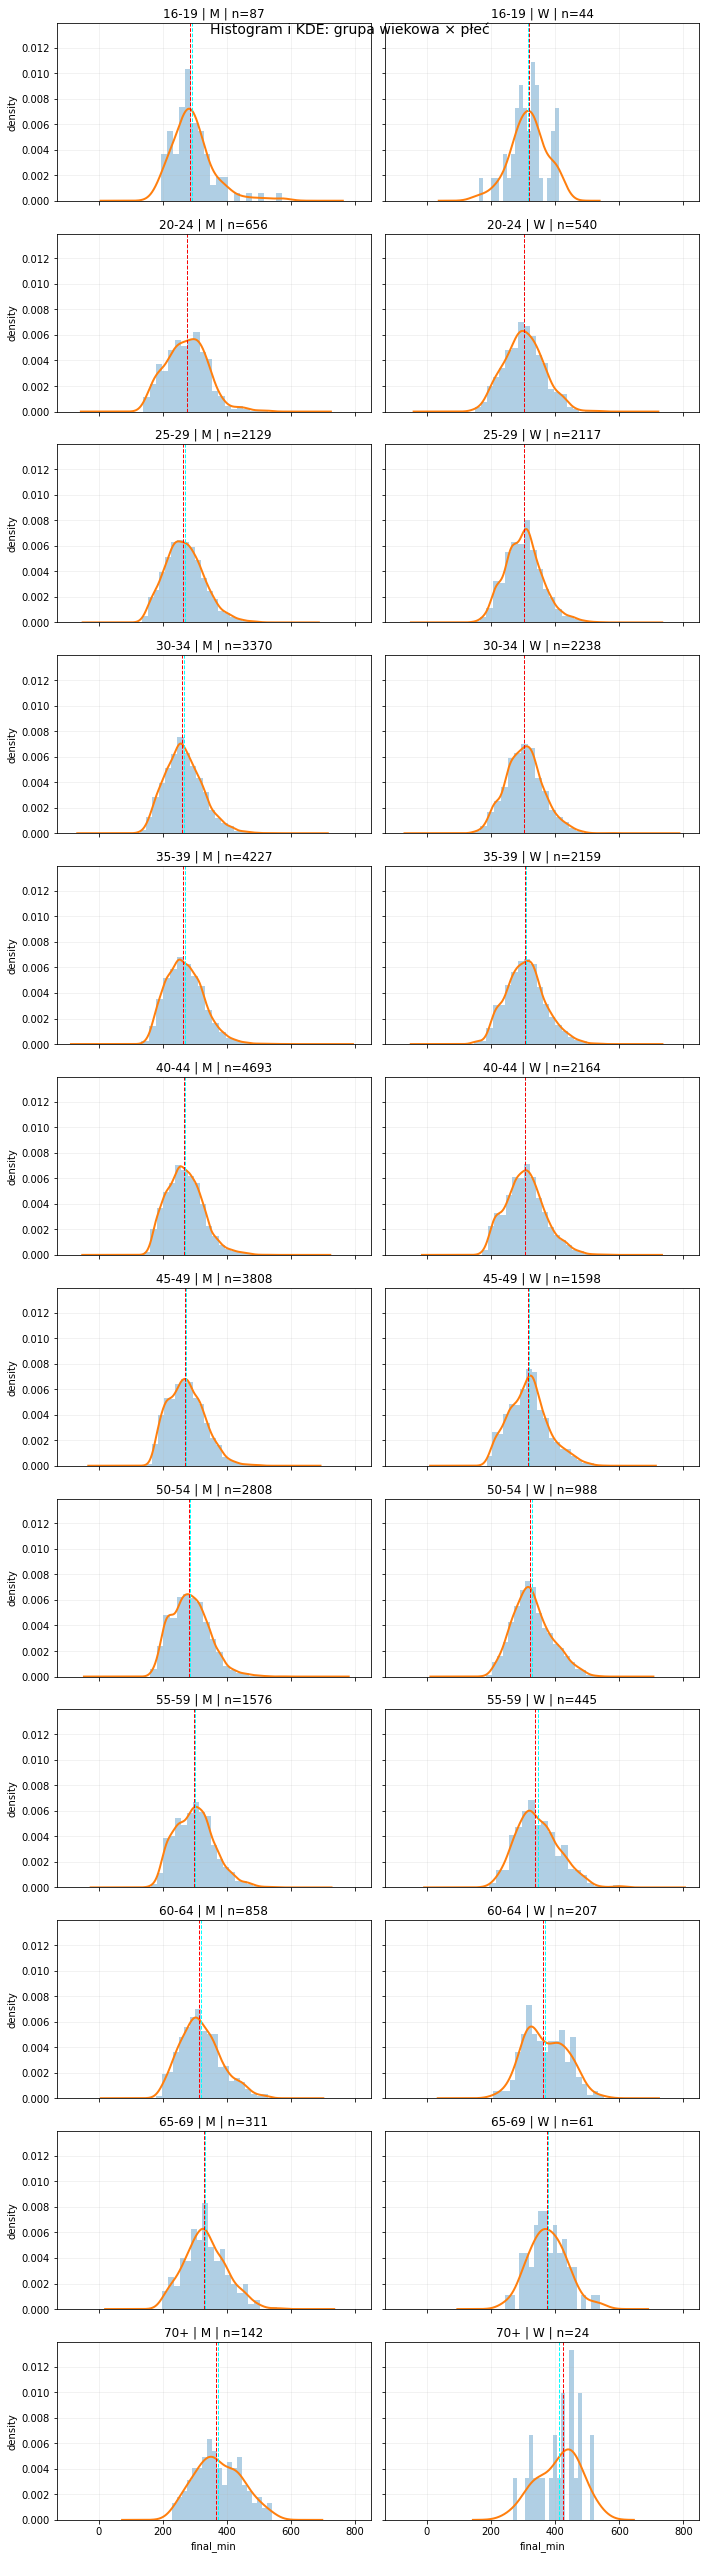

In [78]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(age_labels), 2, figsize=(10, 3*len(age_labels)), sharex=True, sharey=True)

for i, group in enumerate(age_labels):
    for j, gender in enumerate(['M', 'W']):
        ax = axes[i, j]
        sub = df[(df['age_group'] == group) & (df['gender'] == gender)]['final_min'].dropna()

        sub.plot(kind='hist', bins=20, density=True, alpha=0.35, ax=ax)

        if len(sub) > 10:
            sub.plot(kind='density', ax=ax, linewidth=2)

        if len(sub) > 5:
            ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
            ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)

        ax.set_title(f'{group} | {gender} | n={len(sub)}')
        ax.grid(alpha=0.2)

        if i == len(age_labels) - 1:
            ax.set_xlabel('final_min')
        if j == 0:
            ax.set_ylabel('density')

fig.suptitle('Histogram i KDE: grupa wiekowa × płeć', fontsize=14)
fig.tight_layout()
plt.show()

### KDE i lognormalny fit

Tutaj porównujemy dwa sposoby opisu rozkładu:
- KDE, czyli wygładzenie danych,
- lognormalny PDF, czyli model statystyczny dla dodatnich, prawoskośnych zmiennych.

To pozwala ocenić, czy lognormalny model dobrze opisuje dane w każdej grupie.

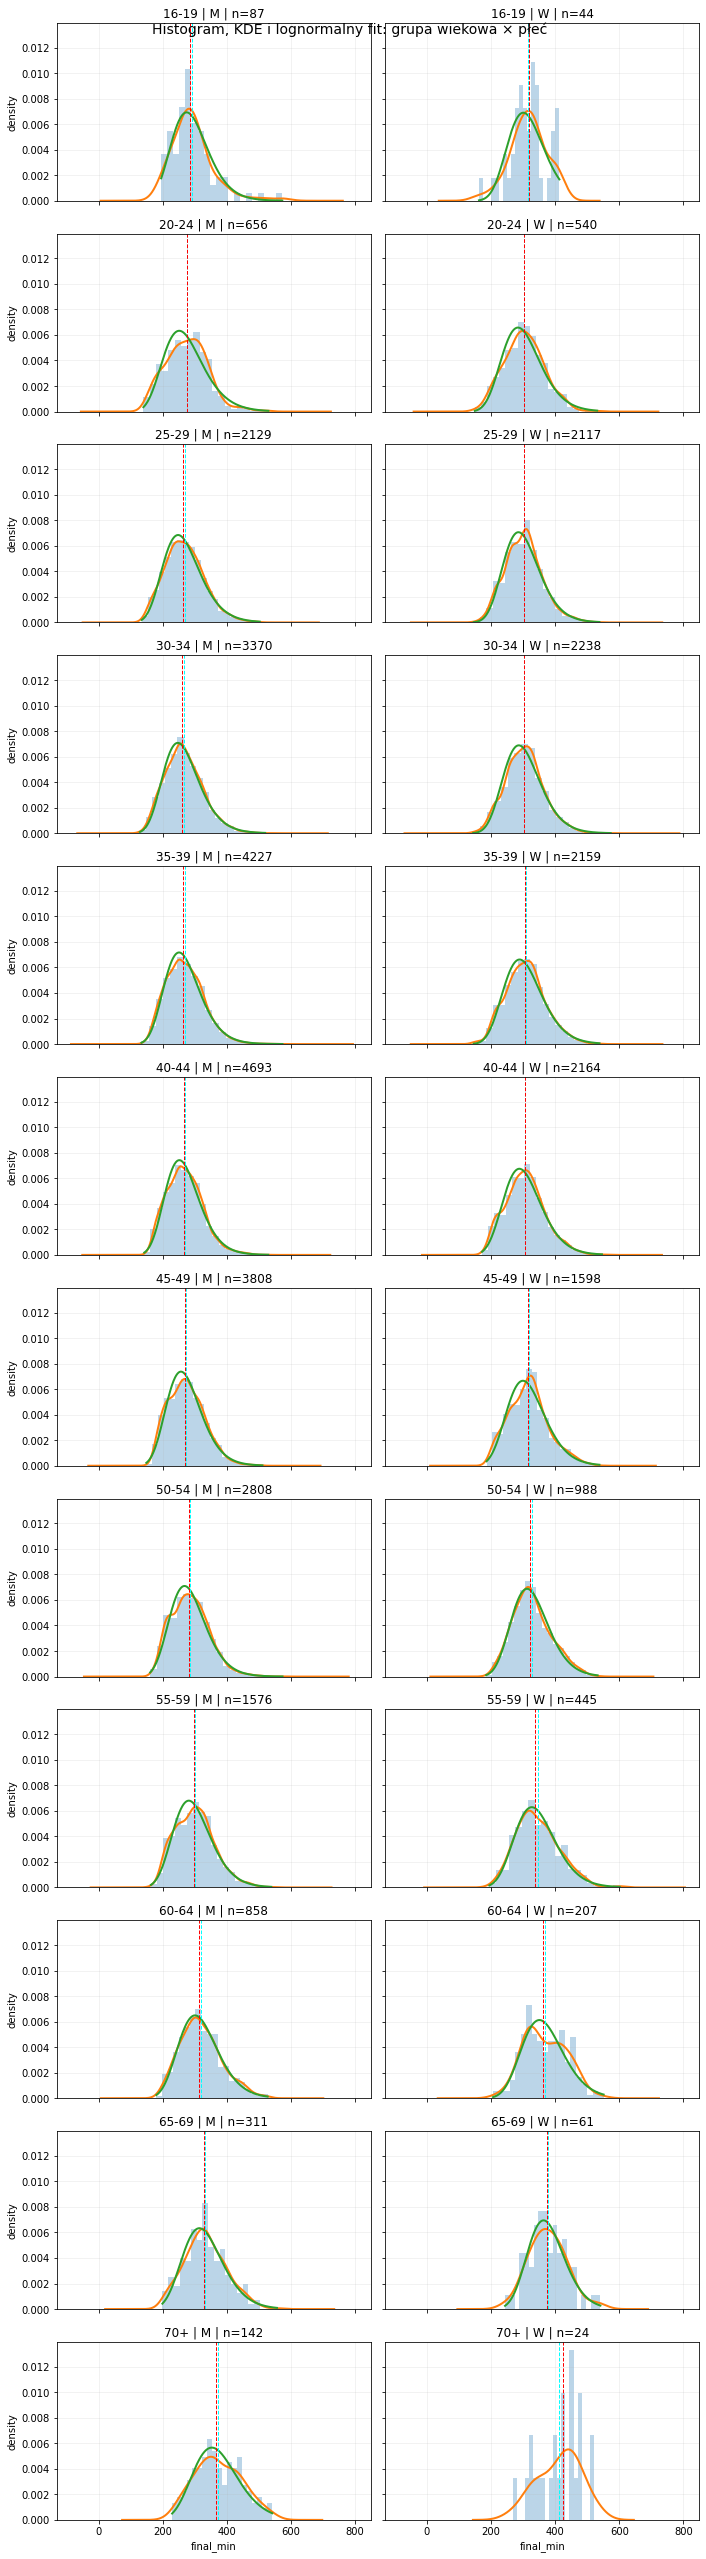

In [80]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(age_labels), 2, figsize=(10, 3*len(age_labels)), sharex=True, sharey=True)

for i, group in enumerate(age_labels):
    for j, gender in enumerate(['M', 'W']):
        ax = axes[i, j]
        sub = df[(df['age_group'] == group) & (df['gender'] == gender)]['final_min'].dropna()

        sub.plot(kind='hist', bins=20, density=True, alpha=0.30, ax=ax)

        if len(sub) > 10:
            sub.plot(kind='density', ax=ax, linewidth=2, label='KDE')

        if len(sub) > 30:
            shape, loc, scale = stats.lognorm.fit(sub, floc=0)
            x = np.linspace(sub.min(), sub.max(), 300)
            pdf = stats.lognorm.pdf(x, s=shape, loc=loc, scale=scale)
            ax.plot(x, pdf, linewidth=2, label='lognormal fit')

        if len(sub) > 5:
            ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
            ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)

        ax.set_title(f'{group} | {gender} | n={len(sub)}')
        ax.grid(alpha=0.2)

        if i == len(age_labels) - 1:
            ax.set_xlabel('final_min')
        if j == 0:
            ax.set_ylabel('density')

fig.suptitle('Histogram, KDE i lognormalny fit: grupa wiekowa × płeć', fontsize=14)
fig.tight_layout()
plt.show()

### Lognormalny i gamma fit

Oba te rozkłady są naturalnymi kandydatami dla dodatnich, prawoskośnych danych.

Porównujemy je, żeby sprawdzić:
- który lepiej opisuje czasy biegu,
- czy dopasowanie zmienia się między grupami,
- oraz czy różnice dotyczą tylko poziomu wyników, czy także modelu rozkładu.

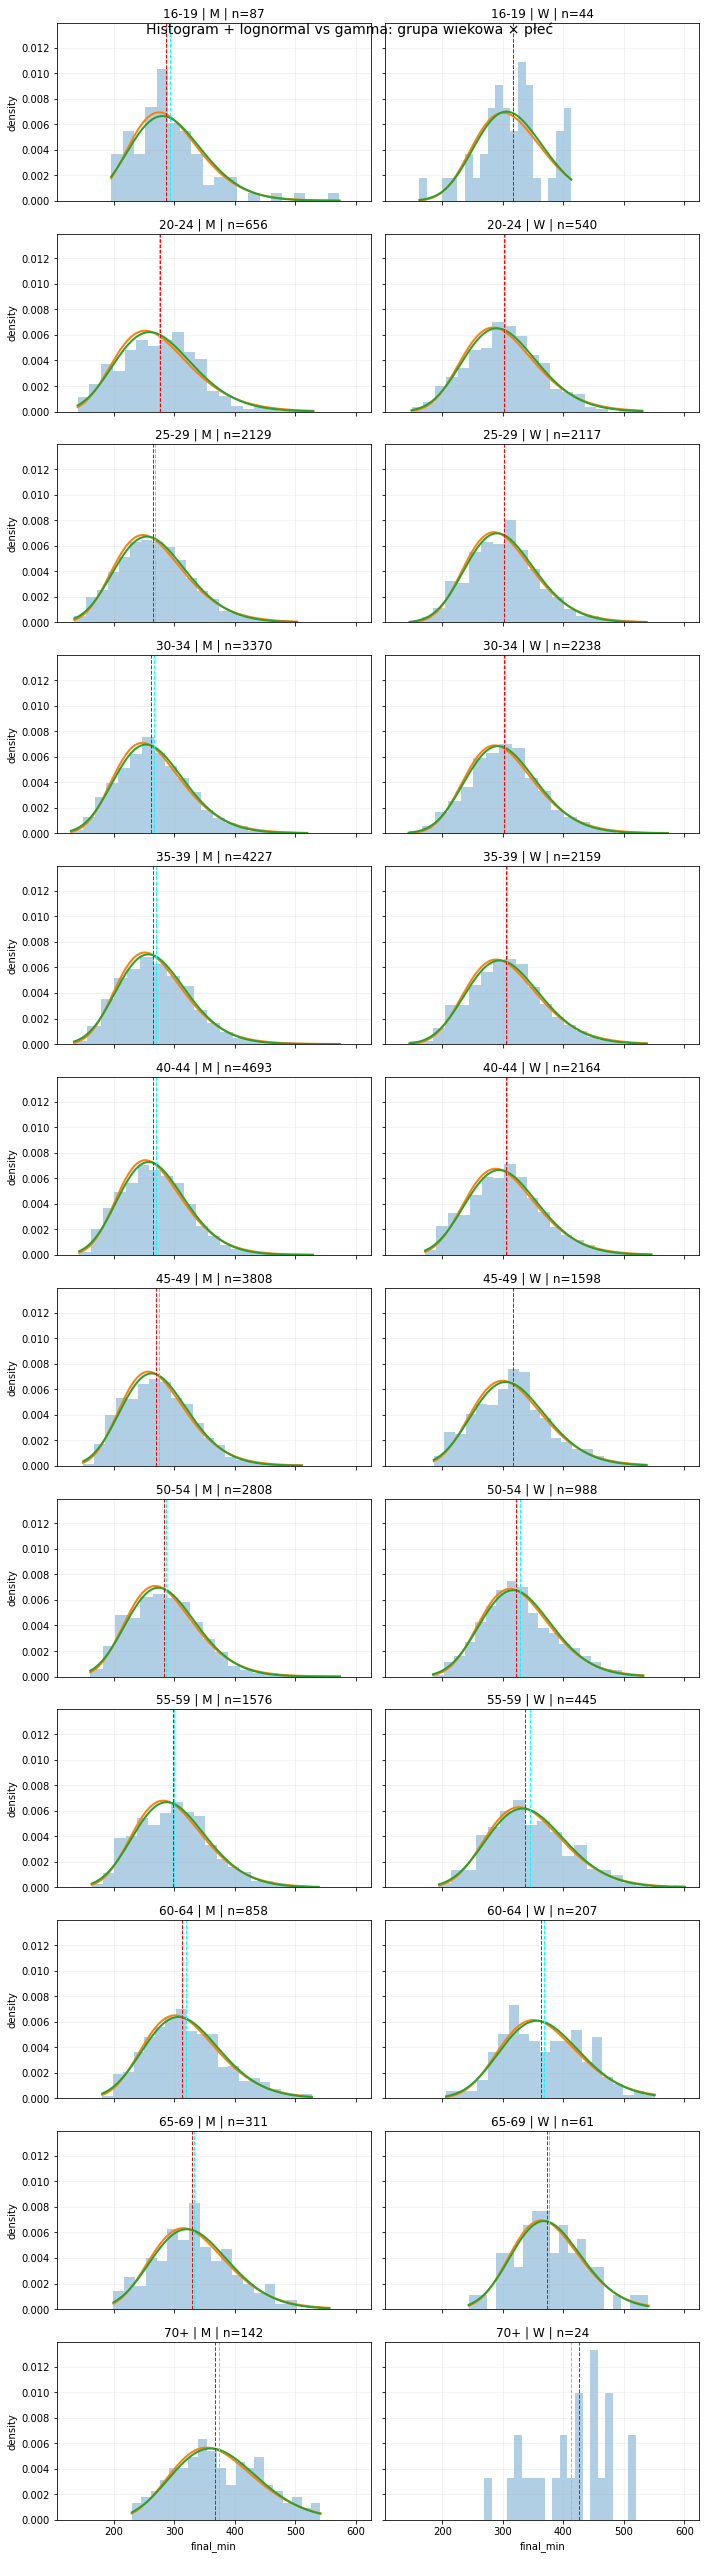

In [81]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(age_labels), 2, figsize=(10, 3*len(age_labels)), sharex=True, sharey=True)

for i, group in enumerate(age_labels):
    for j, gender in enumerate(['M', 'W']):
        ax = axes[i, j]
        sub = df[(df['age_group'] == group) & (df['gender'] == gender)]['final_min'].dropna()

        ax.hist(sub, bins=20, density=True, alpha=0.35)

        if len(sub) > 30:
            x = np.linspace(sub.min(), sub.max(), 300)

            ln_shape, ln_loc, ln_scale = stats.lognorm.fit(sub, floc=0)
            pdf_ln = stats.lognorm.pdf(x, s=ln_shape, loc=ln_loc, scale=ln_scale)

            ga_shape, ga_loc, ga_scale = stats.gamma.fit(sub, floc=0)
            pdf_ga = stats.gamma.pdf(x, a=ga_shape, loc=ga_loc, scale=ga_scale)

            ax.plot(x, pdf_ln, linewidth=2, label='lognormal')
            ax.plot(x, pdf_ga, linewidth=2, label='gamma')

        if len(sub) > 5:
            ax.axvline(sub.mean(), color='cyan', linestyle='--', linewidth=1)
            ax.axvline(sub.median(), color='red', linestyle='--', linewidth=1)

        ax.set_title(f'{group} | {gender} | n={len(sub)}')
        ax.grid(alpha=0.2)

        if i == len(age_labels) - 1:
            ax.set_xlabel('final_min')
        if j == 0:
            ax.set_ylabel('density')

fig.suptitle('Histogram + lognormal vs gamma: grupa wiekowa × płeć', fontsize=14)
fig.tight_layout()
plt.show()

### Wnioski: rozkład czasu końcowego (wiek × płeć)

Analizując histogramy i gęstości dla każdej grupy wiekowej i płci, możemy zauważyć:

**1. Kształt rozkładu jest podobny dla obu płci**
- w każdej grupie wiekowej rozkład jest prawoskośny,
- oznacza to, że mechanizm zmienności wyników jest podobny.

**2. Różnice między płciami polegają głównie na przesunięciu**
- rozkład dla kobiet jest przesunięty w prawo (wyższe czasy),
- ale jego kształt jest bardzo podobny do rozkładu mężczyzn.

👉 Wniosek: różnica dotyczy poziomu wyników, nie struktury rozkładu.

**3. Najszybsze grupy są podobne dla obu płci**
- najlepsze wyniki osiągane są w grupach około 30–44 lat,
- w obu płciach obserwujemy ten sam trend.

**4. Zmienność rośnie wraz z wiekiem**
- starsze grupy mają szersze rozkłady,
- oznacza to większe zróżnicowanie poziomu zawodników.

**5. Małe grupy są niestabilne**
- szczególnie w starszych grupach kobiet (np. 70+),
- histogramy są bardziej poszarpane,
- dopasowanie PDF jest mniej wiarygodne.

👉 Wniosek: przy małych liczebnościach należy ostrożnie interpretować wyniki.

**6. Lognormalny model nadal dobrze opisuje dane**
- we wszystkich grupach wiekowych i dla obu płci,
- co potwierdza, że czasy biegu mają charakter dodatni i prawoskośny.

### Możliwa interpretacja rozkładu w starszych grupach

W bardzo starszych grupach zawodnicy tworzą już populację silnie wyselekcjonowaną:
- muszą zachować zdrowie,
- sprawność,
- zdolność do treningu,
- i motywację do startu.

Oznacza to, że wynik końcowy może być efektem sumy wielu drobnych wpływów biologicznych i treningowych.

W tym sensie rozkład może przypominać bardziej regularny i częściowo symetryczny kształt, podobnie jak suma wielu małych losowych składników.  
To jest intuicja bliska centralnemu twierdzeniu granicznemu, choć w praktyce dane nadal mogą zachowywać pewną skośność.

## 14. `pivot_table` dla spowolnienia

### Spowolnienie: wiek × płeć

Do tej pory analizowaliśmy:
- czas końcowy,
- jego rozkład,
- różnice między grupami.

Teraz patrzymy głębiej — nie na sam wynik, ale na **strategię biegu**.

Tworzymy tabelę przestawną, która pokazuje:
- średnie spowolnienie (`slowdown_min`),
- dla każdej grupy wiekowej,
- osobno dla kobiet i mężczyzn.

Dzięki temu możemy sprawdzić:
- kto bardziej zwalnia na drugiej połowie,
- czy różnice między płciami są stabilne,
- oraz jak strategia biegu zmienia się wraz z wiekiem.

In [73]:
pivot_slow = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='slowdown_min',
    aggfunc='mean',
    observed=False
)

pivot_negative = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='negative_split',
    aggfunc='mean',
    observed=False
)

print('Średnie spowolnienie [min]:')
display(pivot_slow.round(2))

print('Odsetek negative split:')
display(pivot_negative.round(3))

Średnie spowolnienie [min]:


gender,M,W
age_group,,
16-19,43.80,49.29
20-24,41.50,44.30
25-29,37.36,43.31
30-34,35.93,43.24
35-39,36.05,44.05
40-44,35.70,42.79
45-49,37.15,45.12
50-54,40.03,48.58
55-59,43.93,50.49


Odsetek negative split:


gender,M,W
age_group,,
16-19,0.000,0.000
20-24,0.012,0.004
25-29,0.013,0.007
30-34,0.016,0.004
35-39,0.006,0.004
40-44,0.010,0.001
45-49,0.005,0.005
50-54,0.005,0.002
55-59,0.005,0.000


### Wnioski ze spowolnienia

- Spowolnienie rośnie wraz z wiekiem.
- Kobiety mają przeciętnie większe spowolnienie niż mężczyźni.
- `negative split` jest rzadki i zwykle jeszcze rzadszy u kobiet.

> Wniosek: wiek i płeć wpływają nie tylko na wynik końcowy, ale także na strategię biegu.

### Wnioski ze spowolnienia

- W każdej grupie wiekowej kobiety mają średnio większe spowolnienie niż mężczyźni.
- Spowolnienie rośnie wraz z wiekiem dla obu płci.
- Różnice między płciami są dość stabilne — kobiety zwalniają bardziej w każdej kategorii.

👉 Wniosek:
płeć i wiek wpływają nie tylko na wynik końcowy, ale także na sposób rozkładania sił w trakcie biegu.

## 15. Wykres liniowy: średnia i mediana po grupach

### Trend czasu końcowego w funkcji wieku

Zamiast patrzeć na każdą grupę osobno, chcemy zobaczyć ogólny trend.

Rysujemy wykres liniowy, który pokazuje:
- średni czas końcowy,
- medianę czasu końcowego,
- w zależności od grupy wiekowej.

Dzięki temu możemy zobaczyć:
- jak zmienia się wynik wraz z wiekiem,
- czy trend jest liniowy,
- oraz gdzie znajdują się najlepsze wyniki.

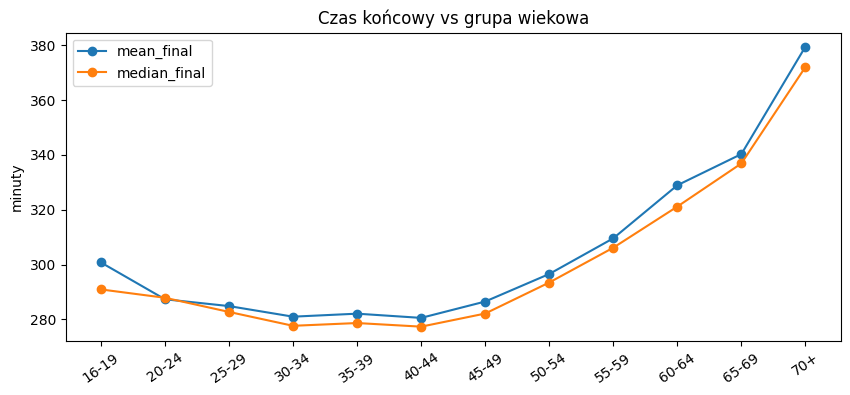

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(age_summary['age_group'].astype(str), age_summary['mean_final'], marker='o', label='mean_final')
plt.plot(age_summary['age_group'].astype(str), age_summary['median_final'], marker='o', label='median_final')
plt.xticks(rotation=35)
plt.ylabel('minuty')
plt.title('Czas końcowy vs grupa wiekowa')
plt.legend()
plt.show()

### Wnioski z trendu wieku

- Najlepsze wyniki osiągane są w średnim wieku (około 30–40 lat).
- Zarówno średnia, jak i mediana pokazują podobny trend, co oznacza stabilny obraz danych.
- Po tym okresie czas biegu systematycznie rośnie.

👉 Wniosek:
wydajność rośnie do pewnego momentu, a następnie stopniowo spada wraz z wiekiem.

### Error bars - SEM

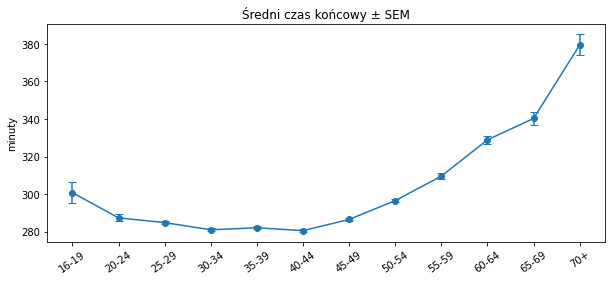

In [74]:
age_err = (
    df.groupby('age_group', observed=False)
      .agg(mean_final=('final_min', 'mean'), sem_final=('final_min', 'sem'))
      .reset_index()
)

plt.figure(figsize=(10, 4))
plt.errorbar(
    age_err['age_group'].astype(str),
    age_err['mean_final'],
    yerr=age_err['sem_final'],
    fmt='o-',
    capsize=4
)
plt.xticks(rotation=35)
plt.title('Średni czas końcowy ± SEM')
plt.ylabel('minuty')
plt.show()

### Error bars - std

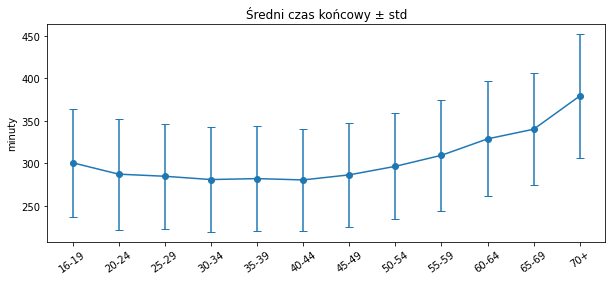

In [75]:

age_err = (
    df.groupby('age_group', observed=False)
      .agg(mean_final=('final_min', 'mean'), std_final=('final_min', 'std'))
      .reset_index()
)

plt.figure(figsize=(10, 4))
plt.errorbar(
    age_err['age_group'].astype(str),
    age_err['mean_final'],
    yerr=age_err['std_final'],
    fmt='o-',
    capsize=4
)
plt.xticks(rotation=35)
plt.title('Średni czas końcowy ± std')
plt.ylabel('minuty')
plt.show()


SEM (Standard Error of the Mean – Błąd Standardowy Średniej) oraz STD/SD (Standard Deviation – Odchylenie Standardowe) to dwie różne miary statystyczne używane do opisu zmienności danych, które często są mylone. W skrócie: SD mówi o rozproszeniu danych w próbce, a SEM mówi o precyzji oszacowania średniej populacji.

### Jak czytać trend wieku?

Pierwszy wykres pokazuje zmianę średniej i mediany w funkcji wieku.  
Drugi wykres dokłada **SEM**, czyli niepewność estymacji średniej.

👉 To lepsze niż surowe `std`, jeśli chcemy pokazać, jak pewnie oszacowaliśmy średni wynik w danej grupie.

## 16. Wykres słupkowy: średni wynik `age_group × gender`

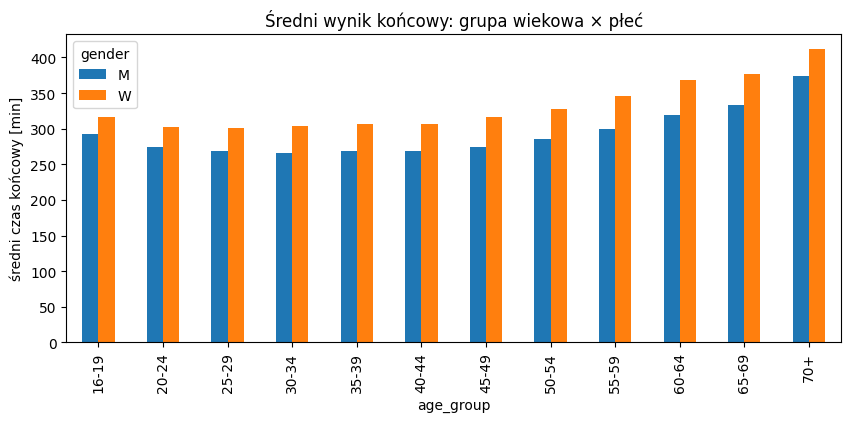

In [18]:

pivot_mean.round(2).plot(kind='bar', figsize=(10, 4))
plt.ylabel('średni czas końcowy [min]')
plt.title('Średni wynik końcowy: grupa wiekowa × płeć')
plt.show()


## 17. Adnotacja na wykresie
Warto czasem podpisać najciekawszy punkt.

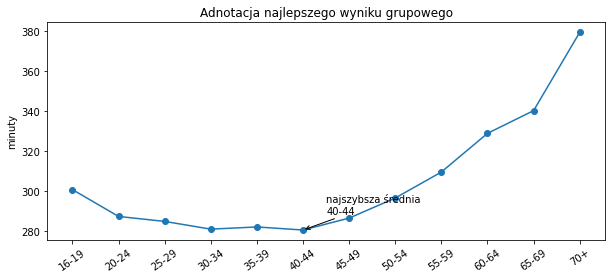

In [76]:

best_row = age_summary.loc[age_summary['mean_final'].idxmin()]

plt.figure(figsize=(10, 4))
plt.plot(age_summary['age_group'].astype(str), age_summary['mean_final'], marker='o')
plt.annotate(
    f"najszybsza średnia\n{best_row['age_group']}",
    xy=(age_summary['age_group'].astype(str)[best_row.name], best_row['mean_final']),
    xytext=(best_row.name + 0.5, best_row['mean_final'] + 8),
    arrowprops=dict(arrowstyle='->')
)
plt.xticks(rotation=35)
plt.ylabel('minuty')
plt.title('Adnotacja najlepszego wyniku grupowego')
plt.show()


## 18. Główne wnioski

1. Dane są dobrze przygotowane do analizy po konwersji czasów do minut i utworzeniu cech `slowdown_min`, `slowdown_pct` i `negative_split`.
2. Rozkład czasu końcowego jest prawoskośny, więc rozkład normalny jest tylko modelem bazowym. Lepiej pasują rozkłady lognormalny lub gamma.
3. Większość zawodników zwalnia na drugiej połowie, a `negative split` występuje rzadko.
4. Zależność `split` i `final` jest bardzo silna, ale częściowo konstrukcyjna.
5. Najszybsze wyniki osiągają zwykle grupy około **30–44 lat**.
6. Płeć wpływa głównie na poziom wyników, a wiek wpływa zarówno na poziom, jak i na zmienność oraz strategię biegu.

In [21]:

summary_points = {
    'najszybsza_grupa_srednia': age_summary.sort_values('mean_final').iloc[0]['age_group'],
    'najszybsza_grupa_mediana': age_summary.sort_values('median_final').iloc[0]['age_group'],
    'najwieksze_spowolnienie_srednio': age_summary.sort_values('mean_slowdown', ascending=False).iloc[0]['age_group'],
    'korelacja_split_final': round(corr, 3),
    'odsetek_negative_split': round(df['negative_split'].mean() * 100, 2)
}
summary_points


{'najszybsza_grupa_srednia': '40-44',
 'najszybsza_grupa_mediana': '40-44',
 'najwieksze_spowolnienie_srednio': '70+',
 'korelacja_split_final': np.float64(0.956),
 'odsetek_negative_split': np.float64(0.67)}

## Główne wnioski z analizy maratończyków

1. Dane są dobrze przygotowane do analizy po konwersji czasów do minut i utworzeniu nowych cech, takich jak `slowdown_min`, `slowdown_pct` i `negative_split`.

2. Rozkład czasu końcowego jest **prawoskośny**, więc prosty model normalny jest tylko przybliżeniem. Dla takich danych warto rozważać także rozkłady lognormalne lub gamma.

3. Większość zawodników **zwalnia na drugiej połowie**, a `negative split` występuje rzadko.

4. Czas na półmetku bardzo silnie wiąże się z czasem końcowym, ale trzeba pamiętać, że ta zależność jest częściowo konstrukcyjna, bo wynik końcowy zawiera w sobie czas z pierwszej połowy.

5. Porównanie grup pokazuje, że najszybsze wyniki osiągają zwykle zawodnicy w wieku około **30–44 lat**.

6. Wszystkie porównania grup należy interpretować razem z ich liczebnością, bo małe grupy mogą dawać mniej stabilne wnioski.

## 19. Pytania / ćwiczenia dla chętnych

1. Czy ranking grup wieku zmienia się bardziej przy średniej czy przy medianie?
2. W których grupach wiekowych różnica `W - M` jest największa?
3. Czy spowolnienie rośnie liniowo z wiekiem?
4. Dlaczego małe grupy mogą wyglądać bardziej „regularnie” lub bardziej „dziwnie” niż duże?
5. Dlaczego w tych danych lognormalny albo gamma ma więcej sensu niż rozkład normalny?

# APPENDIX

## A.1
### Przykład: jak liczymy likelihood i czym jest $f(x)$

Rozważmy bardzo prosty zbiór danych:

$$
x = [1,\;2,\;3]
$$

Załóżmy model: rozkład normalny

$$
f(x;\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

---

### Czym jest $f(x)$?

Wartość:

$$
f(x)
$$

to **gęstość prawdopodobieństwa w punkcie $x$**, a nie prawdopodobieństwo.

Formalnie:

$$
f(x)=\lim_{\Delta x \to 0} \frac{P(x \le X \le x+\Delta x)}{\Delta x}
$$

Czyli:
- $f(x)$ mówi, jak „gęste” jest prawdopodobieństwo w bardzo małym otoczeniu punktu,
- ale samo $P(X=x)=0$ dla rozkładów ciągłych.

---

### Krok 1: wybieramy parametry

Weźmy dwa modele:

#### Model A:
$$
\mu=2,\quad \sigma=1
$$

#### Model B:
$$
\mu=2,\quad \sigma=2
$$

---

### Krok 2: liczymy wartości gęstości $f(x_i)$

#### Model A:

$$
f(1) \approx 0.242,\quad f(2) \approx 0.399,\quad f(3) \approx 0.242
$$

#### Model B:

$$
f(1) \approx 0.176,\quad f(2) \approx 0.199,\quad f(3) \approx 0.176
$$

---

### Krok 3: liczymy likelihood

Likelihood to iloczyn wartości gęstości:

$$
L = \prod_{i=1}^n f(x_i)
$$

#### Model A:

$$
L_A = 0.242 \cdot 0.399 \cdot 0.242 \approx 0.0234
$$

#### Model B:

$$
L_B = 0.176 \cdot 0.199 \cdot 0.176 \approx 0.0062
$$

---

### Interpretacja

- Model A daje większy likelihood → lepiej pasuje do danych
- Model B daje mniejszy likelihood → gorzej pasuje

---

### Co to znaczy?

Likelihood nie jest prawdopodobieństwem danych.

Jest to funkcja, która mierzy:

> jak dobrze model przypisuje dużą gęstość w punktach, w których znajdują się dane

---

### Dlaczego to działa?

Choć $f(x_i)$ nie jest prawdopodobieństwem, to:

- jeśli model daje duże wartości $f(x_i)$ dla danych,
- to znaczy, że dane leżą w „gęstych” obszarach rozkładu,
- więc model dobrze je opisuje.

---

### Log-likelihood (praktyka)

Zamiast iloczynu używamy sumy logarytmów:

$$
\ell = \sum_{i=1}^n \log f(x_i)
$$

To jest dokładnie to, co maksymalizuje funkcja `fit()`.

---

### Podsumowanie

- $f(x)$ = gęstość prawdopodobieństwa (nie prawdopodobieństwo)
- likelihood = iloczyn gęstości w punktach danych
- log-likelihood = suma logarytmów tych gęstości
- najlepsze parametry to te, które maksymalizują log-likelihood


### Dokładniejsze porównanie metod dopasowania modeli

Gdy dopasowujemy kilka rozkładów do tych samych danych $x_1, x_2, \dots, x_n$, chcemy ocenić, który model najlepiej opisuje obserwacje.

Zakładamy, że dany model ma gęstość prawdopodobieństwa:

$$
f(x;\theta),
$$

gdzie $\theta$ oznacza zestaw parametrów modelu.

---

#### 1. Likelihood

Likelihood, czyli funkcja wiarygodności, mierzy jak dobrze dane parametry modelu tłumaczą obserwowane dane.

Dla niezależnych obserwacji:

$$
L(\theta)=\prod_{i=1}^n f(x_i;\theta).
$$

Im większa wartość $L(\theta)$, tym lepiej model pasuje do danych.

W praktyce iloczyn wielu małych liczb jest niewygodny numerycznie, dlatego używa się logarytmu.

---

#### 2. Log-likelihood

Log-likelihood to logarytm funkcji wiarygodności:

$$
\ell(\theta)=\log L(\theta)=\sum_{i=1}^n \log f(x_i;\theta).
$$

To podstawowa miara jakości dopasowania.

Interpretacja:
- większa wartość $\ell(\theta)$ oznacza lepsze dopasowanie,
- często wartości są ujemne, więc „większa” znaczy po prostu „mniej ujemna”.

Dopasowanie przez `fit(...)` w wielu rozkładach można rozumieć jako szukanie parametrów, które maksymalizują log-likelihood.

---

#### 3. MLE: estymacja największej wiarygodności

Metoda największej wiarygodności, czyli Maximum Likelihood Estimation, polega na znalezieniu takich parametrów $\hat{\theta}$, które maksymalizują funkcję wiarygodności:

$$
\hat{\theta}=\arg\max_{\theta} L(\theta),
$$

albo równoważnie:

$$
\hat{\theta}=\arg\max_{\theta} \ell(\theta).
$$

To właśnie najczęściej robi funkcja `fit` w `scipy.stats`.

---

#### 4. AIC

AIC, czyli Akaike Information Criterion, to kryterium porównujące modele z uwzględnieniem liczby parametrów.

Definicja:

$$
AIC = 2k - 2\ell(\hat{\theta}),
$$

gdzie:
- $k$ to liczba estymowanych parametrów,
- $\ell(\hat{\theta})$ to maksymalny log-likelihood.

Interpretacja:
- mniejsze AIC oznacza lepszy model,
- pierwszy składnik $2k$ karze za zbyt dużą liczbę parametrów,
- drugi składnik nagradza dobre dopasowanie.

AIC szuka więc kompromisu:
- model ma dobrze opisywać dane,
- ale nie powinien być niepotrzebnie złożony.

---

#### 5. BIC

BIC, czyli Bayesian Information Criterion, jest podobne do AIC, ale mocniej karze bardziej złożone modele.

Definicja:

$$
BIC = k \ln(n) - 2\ell(\hat{\theta}),
$$

gdzie:
- $k$ to liczba parametrów,
- $n$ to liczba obserwacji,
- $\ell(\hat{\theta})$ to maksymalny log-likelihood.

Interpretacja:
- mniejsze BIC oznacza lepszy model,
- kara za złożoność rośnie wraz z liczebnością próby.

W praktyce:
- AIC częściej wybiera model lepiej dopasowany,
- BIC częściej wybiera model prostszy.

---

### Jak interpretować wyniki?

Jeśli porównujemy kilka modeli dopasowanych do tych samych danych, to:

- **największy log-likelihood** oznacza najlepsze dopasowanie do danych,
- **najmniejsze AIC** oznacza najlepszy kompromis między dopasowaniem i złożonością,
- **najmniejsze BIC** oznacza najlepszy model przy silniejszej karze za nadmiar parametrów.

---

### Ważna uwaga

AIC i BIC mają sens głównie przy porównywaniu modeli dopasowanych:
- do tych samych danych,
- tą samą metodą,
- przy tej samej interpretacji liczby parametrów.

Nie patrzymy zwykle na ich wartość bezwzględną, tylko porównujemy je między modelami.

---

### Krótkie podsumowanie

- Log-likelihood: im większy, tym lepiej.
- AIC: im mniejszy, tym lepiej.
- BIC: im mniejszy, tym lepiej.
- `fit(...)` zwykle szuka parametrów przez metodę największej wiarygodności.

# A.2